# Linear Algebra Symbols and Basics for Machine Learning

A polished, concept-by-concept notebook for learning the symbols, theory, examples, and visual intuition behind linear algebra in machine learning.

Each block follows the same professional structure:

- **Concept**: what the idea means.
- **Notation**: the mathematical symbols to recognize.
- **Theory**: the key fact worth remembering.
- **Math example**: a hand-computable example.
- **Best ML example**: where the idea appears in machine learning.
- **Visualization**: runnable Python code that makes the idea visible.

Run the notebook from top to bottom, then change numbers in each code cell and rerun. That is where the ideas become yours.


In [95]:
# Global setup for the whole notebook
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

COLORS = {
    "blue": "#2563eb",
    "green": "#16a34a",
    "red": "#dc2626",
    "purple": "#7c3aed",
    "orange": "#f97316",
    "gray": "#475569",
    "light": "#e2e8f0",
}


def setup_2d_axis(ax, limit=4, title=None):
    ax.axhline(0, color="#111827", linewidth=1)
    ax.axvline(0, color="#111827", linewidth=1)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.35)
    if title:
        ax.set_title(title, fontsize=12, weight="bold")


def draw_vector(ax, v, origin=(0, 0), color="#2563eb", label=None, width=0.012):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)
    ax.arrow(
        origin[0],
        origin[1],
        v[0],
        v[1],
        head_width=0.16,
        head_length=0.22,
        length_includes_head=True,
        linewidth=2,
        color=color,
        width=width,
    )
    if label:
        end = origin + v
        ax.text(end[0] + 0.12, end[1] + 0.12, label, color=color, fontsize=11, weight="bold")


def show_matrix(ax, M, title, cmap="Blues", vmin=None, vmax=None):
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M[i, j]:.1f}", ha="center", va="center", fontsize=11)
    return im


## Block 01 - Scalars: single numbers that scale meaning

**Concept.** A scalar is one number. It can represent a learning rate, probability, loss value, weight, or temperature.

**Notation.** Scalars are often lowercase italic letters: $a, b, c, \lambda, \alpha \in \mathbb{R}$.

**Theory.** Multiplying a vector by a scalar changes its length and possibly its direction:

$$\alpha\mathbf{x}=[\alpha x_1,\alpha x_2,\ldots,\alpha x_n]^T$$

**Math example.** If $\alpha=2.5$ and $\mathbf{x}=[2,1]^T$, then $\alpha\mathbf{x}=[5,2.5]^T$.

**Best ML example.** The learning rate $\eta$ in gradient descent is a scalar that controls step size.

**Visualization.** The same vector is scaled by several scalar values.


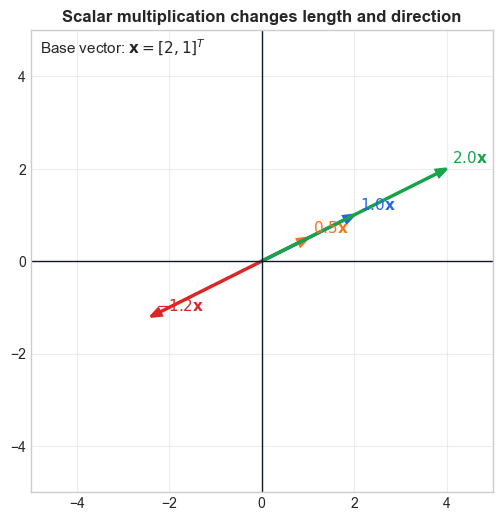

In [96]:
x = np.array([2.0, 1.0])
scalars = [-1.2, 0.5, 1.0, 2.0]
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=5, title="Scalar multiplication changes length and direction")
for alpha, color in zip(scalars, [COLORS["red"], COLORS["orange"], COLORS["blue"], COLORS["green"]]):
    draw_vector(ax, alpha * x, color=color, label=fr"${alpha}\mathbf{{x}}$")
ax.text(-4.8, 4.5, r"Base vector: $\mathbf{x}=[2,1]^T$", fontsize=11)
plt.show()


**Graph explanation.** The arrows share the same base vector but use different scalar multipliers. Longer arrows show stretching, shorter arrows show shrinking, and the arrow pointing in the opposite direction shows what happens when the scalar is negative.


## Block 02 - Vectors: ordered coordinates with direction

**Concept.** A vector is an ordered list of numbers. Geometrically, it is an arrow; in ML, it is often one data point or one row of features.

**Notation.** Bold lowercase letters: $\mathbf{x}\in\mathbb{R}^n$.

$$\mathbf{x}=\begin{bmatrix}x_1\\x_2\\\vdots\\x_n\end{bmatrix}$$

**Theory.** Order matters: $[2,5]^T\ne[5,2]^T$.

**Math example.** A house can be represented as $\mathbf{x}=[\text{area},\text{bedrooms}]^T=[1200,3]^T$.

**Best ML example.** A model receives each training sample as a feature vector.

**Visualization.** Two vectors with the same numbers in different order point differently.


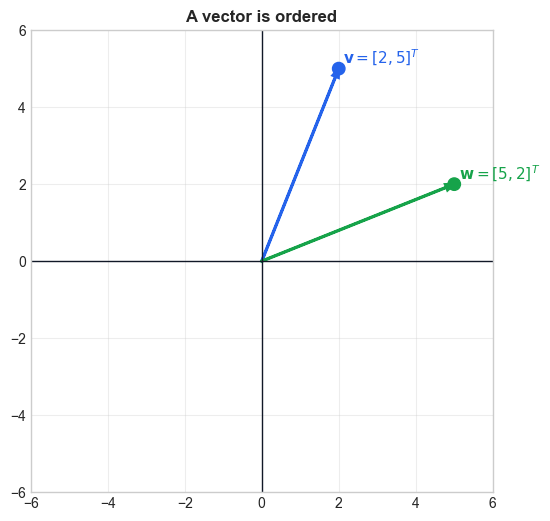

In [97]:
v = np.array([2, 5])
w = np.array([5, 2])
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=6, title="A vector is ordered")
draw_vector(ax, v, color=COLORS["blue"], label=r"$\mathbf{v}=[2,5]^T$")
draw_vector(ax, w, color=COLORS["green"], label=r"$\mathbf{w}=[5,2]^T$")
ax.scatter([v[0], w[0]], [v[1], w[1]], s=80, c=[COLORS["blue"], COLORS["green"]])
plt.show()


**Graph explanation.** The plot shows that vector coordinates are ordered. Swapping the same two numbers changes the endpoint and direction, which is why feature order must stay consistent in machine learning.


## Block 03 - Matrices: data tables and linear operators

**Concept.** A matrix is a rectangular array of numbers. It can store a dataset or act as a transformation.

**Notation.** Bold uppercase letters: $\mathbf{A}\in\mathbb{R}^{m\times n}$.

**Theory.** Shape matters. An $m\times n$ matrix has $m$ rows and $n$ columns.

**Math example.** A $3\times2$ matrix can store 3 samples and 2 features.

**Best ML example.** The feature matrix $\mathbf{X}\in\mathbb{R}^{m\times n}$ stores $m$ training examples with $n$ features.

**Visualization.** A heatmap turns matrix values into intensity.


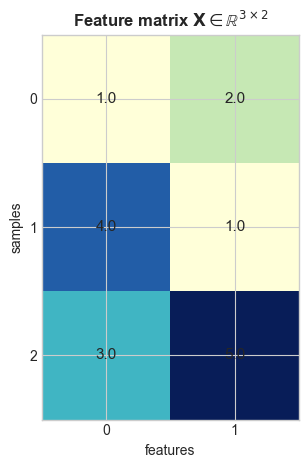

A.shape = (3, 2)


In [98]:
A = np.array([[1, 2], [4, 1], [3, 5]], dtype=float)
fig, ax = plt.subplots(figsize=(5, 5))
show_matrix(ax, A, r"Feature matrix $\mathbf{X}\in\mathbb{R}^{3\times2}$", cmap="YlGnBu")
ax.set_xlabel("features")
ax.set_ylabel("samples")
plt.show()
print("A.shape =", A.shape)


**Graph explanation.** The heatmap treats each matrix entry as a colored cell. Rows represent samples, columns represent features, and the color intensity helps you quickly see which values are large or small.


## Block 04 - Entries, rows, columns, and shape literacy

**Concept.** Matrix literacy begins with knowing exactly which number is being referenced.

**Notation.** $a_{ij}$ means row $i$, column $j$. In Python, indexing starts at 0, so math $a_{23}$ is `A[1, 2]`.

**Theory.** Rows often represent observations; columns often represent variables or features.

**Math example.** If $\mathbf{A}=\begin{bmatrix}10&20&30\\40&50&60\end{bmatrix}$, then $a_{23}=60$.

**Best ML example.** `X[i, j]` is feature $j$ for training sample $i$.

**Visualization.** The highlighted cell is $a_{23}$ in math notation.


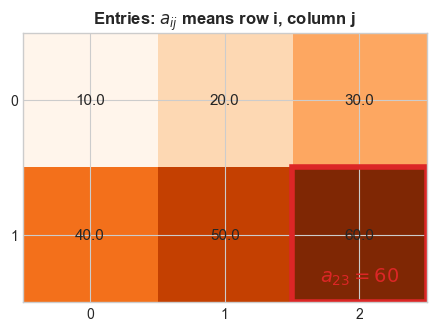

Math a_23 equals Python A[1, 2] = 60


In [99]:
A = np.array([[10, 20, 30], [40, 50, 60]])
fig, ax = plt.subplots(figsize=(6, 3.5))
show_matrix(ax, A, r"Entries: $a_{ij}$ means row i, column j", cmap="Oranges")
ax.add_patch(plt.Rectangle((1.5, 0.5), 1, 1, fill=False, edgecolor=COLORS["red"], linewidth=4))
ax.text(2, 1.35, r"$a_{23}=60$", ha="center", color=COLORS["red"], fontsize=14, weight="bold")
plt.show()
print("Math a_23 equals Python A[1, 2] =", A[1, 2])


**Graph explanation.** The highlighted cell connects math indexing to Python indexing. Math uses row 2, column 3 for $a_{23}$, while NumPy uses `A[1, 2]` because Python starts counting at zero.


## Block 05 - Transpose: rows become columns

**Concept.** The transpose flips a matrix over its main diagonal.

**Notation.** $\mathbf{A}^T$.

**Theory.** If $\mathbf{A}\in\mathbb{R}^{m\times n}$, then $\mathbf{A}^T\in\mathbb{R}^{n\times m}$ and $(\mathbf{A}^T)^T=\mathbf{A}$.

**Math example.** $\begin{bmatrix}1&2&3\\4&5&6\end{bmatrix}^T=\begin{bmatrix}1&4\\2&5\\3&6\end{bmatrix}$.

**Best ML example.** $\mathbf{X}^T\mathbf{X}$ appears in linear regression, covariance, and PCA.

**Visualization.** The original matrix and its transpose are shown side by side.


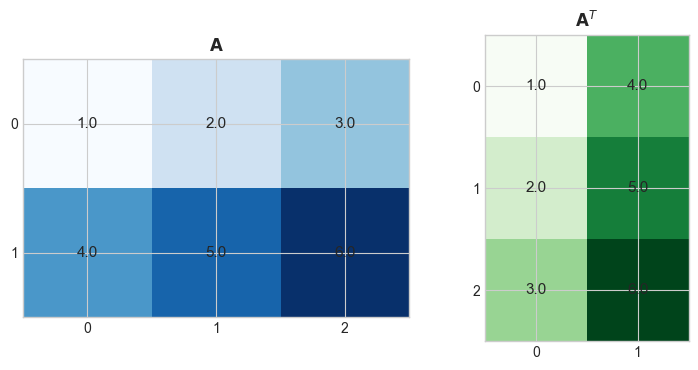

A.T @ A =
 [[17. 22. 27.]
 [22. 29. 36.]
 [27. 36. 45.]]


In [100]:
A = np.array([[1, 2, 3], [4, 5, 6]], dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
show_matrix(axes[0], A, r"$\mathbf{A}$", cmap="Blues")
show_matrix(axes[1], A.T, r"$\mathbf{A}^T$", cmap="Greens")
plt.tight_layout()
plt.show()
print("A.T @ A =\n", A.T @ A)


**Graph explanation.** The side-by-side matrices show rows becoming columns. Notice how the original 2 by 3 matrix becomes a 3 by 2 matrix after transposition.


## Block 06 - Linear combinations: building new vectors from old ones

**Concept.** A linear combination mixes vectors using scalar weights.

**Notation.** $c_1\mathbf{v}_1+c_2\mathbf{v}_2+\cdots+c_k\mathbf{v}_k$.

**Theory.** Linear algebra studies what can be built when only scaling and adding are allowed.

**Math example.** If $\mathbf{v}_1=[1,0]^T$ and $\mathbf{v}_2=[1,1]^T$, then $2\mathbf{v}_1+3\mathbf{v}_2=[5,3]^T$.

**Best ML example.** Linear regression predicts by combining feature columns with learned weights.

**Visualization.** The purple vector is assembled from two scaled vectors.


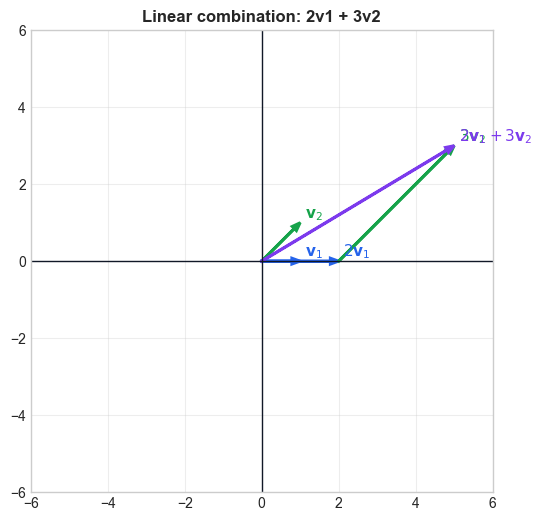

Result: [5. 3.]


In [101]:
v1 = np.array([1.0, 0.0])
v2 = np.array([1.0, 1.0])
c1, c2 = 2, 3
combo = c1 * v1 + c2 * v2
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=6, title="Linear combination: 2v1 + 3v2")
draw_vector(ax, v1, color=COLORS["blue"], label=r"$\mathbf{v}_1$")
draw_vector(ax, v2, color=COLORS["green"], label=r"$\mathbf{v}_2$")
draw_vector(ax, c1 * v1, color=COLORS["blue"], label=r"$2\mathbf{v}_1$")
draw_vector(ax, c2 * v2, origin=c1 * v1, color=COLORS["green"], label=r"$3\mathbf{v}_2$")
draw_vector(ax, combo, color=COLORS["purple"], label=r"$2\mathbf{v}_1+3\mathbf{v}_2$")
plt.show()
print("Result:", combo)


**Graph explanation.** The plot shows that vector coordinates are ordered. Swapping the same two numbers changes the endpoint and direction, which is why feature order must stay consistent in machine learning.


## Block 07 - Span and basis: what vectors can reach

**Concept.** The span of vectors is the set of all linear combinations they can create. A basis is a minimal set that spans a space.

**Notation.** $\operatorname{span}(\mathbf{v}_1,\mathbf{v}_2)$.

**Theory.** In $\mathbb{R}^2$, two non-collinear vectors span the plane; collinear vectors span only a line.

**Math example.** $[1,0]^T$ and $[0,1]^T$ form the standard basis for $\mathbb{R}^2$.

**Best ML example.** Feature engineering tries to create a useful basis for representing patterns.

**Visualization.** Independent vectors create a grid; dependent vectors collapse to a line.


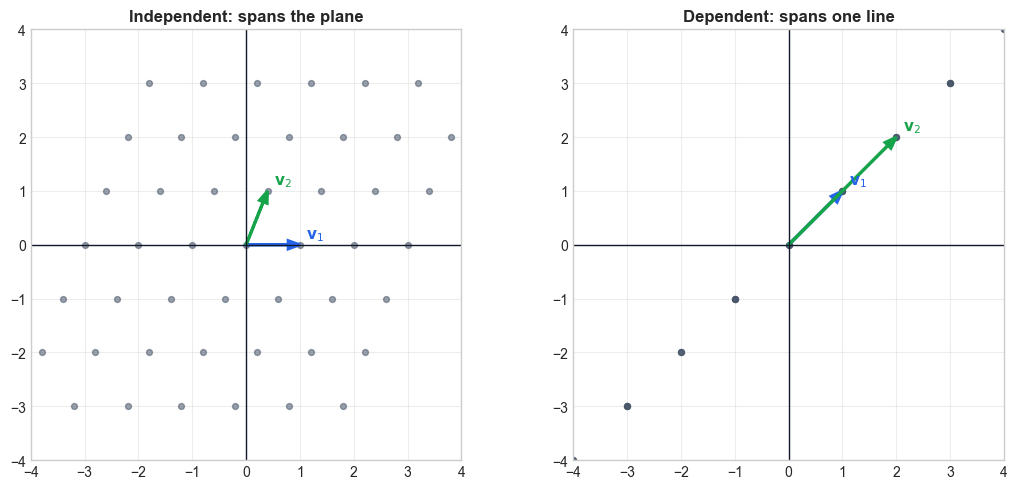

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, vectors, title in [
    (axes[0], [np.array([1, 0]), np.array([0.4, 1])], "Independent: spans the plane"),
    (axes[1], [np.array([1, 1]), np.array([2, 2])], "Dependent: spans one line"),
]:
    setup_2d_axis(ax, limit=4, title=title)
    v1, v2 = vectors
    for a in range(-3, 4):
        for b in range(-3, 4):
            point = a * v1 + b * v2
            ax.scatter(point[0], point[1], s=18, color=COLORS["gray"], alpha=0.55)
    draw_vector(ax, v1, color=COLORS["blue"], label=r"$\mathbf{v}_1$")
    draw_vector(ax, v2, color=COLORS["green"], label=r"$\mathbf{v}_2$")
plt.tight_layout()
plt.show()


**Graph explanation.** The plot shows that vector coordinates are ordered. Swapping the same two numbers changes the endpoint and direction, which is why feature order must stay consistent in machine learning.


## Block 08 - Norms and distance: measuring vector size

**Concept.** A norm measures vector length or magnitude.

**Notation.** Common norms: $\|\mathbf{x}\|_1$, $\|\mathbf{x}\|_2$, $\|\mathbf{x}\|_\infty$.

**Theory.** The Euclidean norm is $\|\mathbf{x}\|_2=\sqrt{x_1^2+\cdots+x_n^2}$.

**Math example.** For $\mathbf{x}=[3,4]^T$, $\|\mathbf{x}\|_2=5$.

**Best ML example.** Regularization controls model complexity using norms, such as L1 in Lasso and L2 in Ridge regression.

**Visualization.** Different norms define different unit balls.


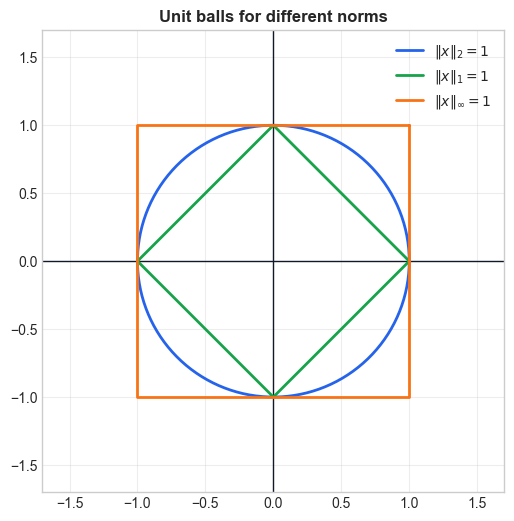

In [103]:
t = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=1.7, title="Unit balls for different norms")
ax.plot(np.cos(t), np.sin(t), color=COLORS["blue"], linewidth=2, label=r"$\|x\|_2=1$")
diamond = np.array([[1,0], [0,1], [-1,0], [0,-1], [1,0]])
square = np.array([[1,1], [-1,1], [-1,-1], [1,-1], [1,1]])
ax.plot(diamond[:,0], diamond[:,1], color=COLORS["green"], linewidth=2, label=r"$\|x\|_1=1$")
ax.plot(square[:,0], square[:,1], color=COLORS["orange"], linewidth=2, label=r"$\|x\|_\infty=1$")
ax.legend(loc="upper right")
plt.show()


**Graph explanation.** Each boundary contains points with norm equal to 1. The circle, diamond, and square show that different norms define different ideas of distance.


## Block 09 - Dot product: alignment and similarity

**Concept.** The dot product measures how much two vectors point in the same direction.

**Notation.** $\mathbf{x}\cdot\mathbf{y}=\mathbf{x}^T\mathbf{y}=\langle\mathbf{x},\mathbf{y}\rangle$.

**Theory.** $\mathbf{x}^T\mathbf{y}=\|\mathbf{x}\|\|\mathbf{y}\|\cos\theta$.

**Math example.** $[2,1]^T\cdot[1,3]^T=2\cdot1+1\cdot3=5$.

**Best ML example.** Neural network layers and linear regression use dot products for weighted sums.

**Visualization.** A smaller angle gives a larger positive dot product.


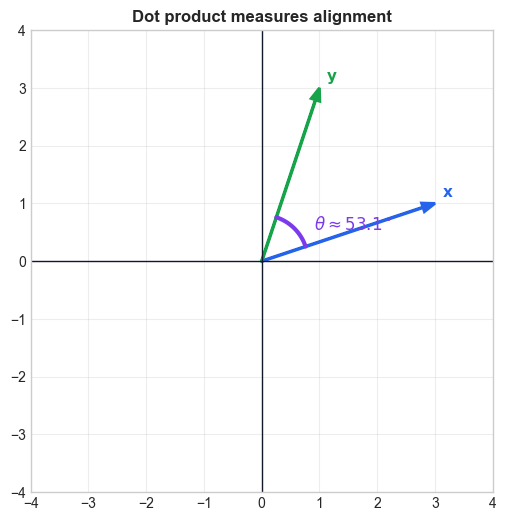

x dot y = 6  | cosine similarity = 0.6


In [104]:
x = np.array([3, 1])
y = np.array([1, 3])
dot = x @ y
cosine = dot / (np.linalg.norm(x) * np.linalg.norm(y))
angle = np.degrees(np.arccos(cosine))
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=4, title="Dot product measures alignment")
draw_vector(ax, x, color=COLORS["blue"], label=r"$\mathbf{x}$")
draw_vector(ax, y, color=COLORS["green"], label=r"$\mathbf{y}$")
arc = np.linspace(np.arctan2(x[1], x[0]), np.arctan2(y[1], y[0]), 80)
ax.plot(0.8*np.cos(arc), 0.8*np.sin(arc), color=COLORS["purple"], linewidth=3)
ax.text(0.9, 0.55, fr"$\theta\approx{angle:.1f}^\circ$", color=COLORS["purple"], fontsize=12)
plt.show()
print("x dot y =", dot, " | cosine similarity =", round(cosine, 3))


**Graph explanation.** The angle arc shows why dot products measure alignment. Vectors pointing in similar directions have a larger positive dot product.


## Block 10 - Projection: the shadow of one vector on another

**Concept.** Projection finds the part of one vector that lies in the direction of another.

**Notation.** $\operatorname{proj}_{\mathbf{u}}(\mathbf{x})=\frac{\mathbf{x}^T\mathbf{u}}{\mathbf{u}^T\mathbf{u}}\mathbf{u}$.

**Theory.** The residual $\mathbf{x}-\operatorname{proj}_{\mathbf{u}}(\mathbf{x})$ is perpendicular to $\mathbf{u}$.

**Math example.** Projecting $[3,2]^T$ onto $[2,0]^T$ gives $[3,0]^T$.

**Best ML example.** Least squares regression projects targets onto the column space of the feature matrix.

**Visualization.** The projection is the shadow; the residual is perpendicular.


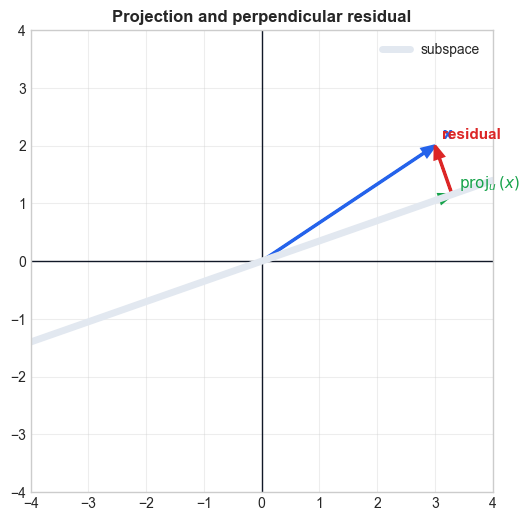

projection = [3.296 1.154]
residual dot u = -0.0


In [105]:
x = np.array([3.0, 2.0])
u = np.array([2.0, 0.7])
proj = (x @ u) / (u @ u) * u
resid = x - proj
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=4, title="Projection and perpendicular residual")
line = np.outer(np.linspace(-2, 2, 20), u)
ax.plot(line[:,0], line[:,1], color=COLORS["light"], linewidth=5, label="subspace")
draw_vector(ax, x, color=COLORS["blue"], label=r"$\mathbf{x}$")
draw_vector(ax, proj, color=COLORS["green"], label=r"$\operatorname{proj}_u(x)$")
draw_vector(ax, resid, origin=proj, color=COLORS["red"], label="residual")
ax.legend()
plt.show()
print("projection =", proj)
print("residual dot u =", round(resid @ u, 10))


**Graph explanation.** The green vector is the shadow of the blue vector on the chosen direction. The red residual meets the green direction at a right angle, showing the orthogonality property.


## Block 11 - Matrix-vector product: weighted columns

**Concept.** Multiplying a matrix by a vector creates a linear combination of the matrix columns.

**Notation.** If $\mathbf{A}=[\mathbf{a}_1\ \mathbf{a}_2]$, then $\mathbf{A}\mathbf{x}=x_1\mathbf{a}_1+x_2\mathbf{a}_2$.

**Theory.** Matrix-vector multiplication is valid when inner dimensions match: $(m\times n)(n\times1)=(m\times1)$.

**Math example.** $\begin{bmatrix}1&2\\3&1\end{bmatrix}\begin{bmatrix}2\\-1\end{bmatrix}=2[1,3]^T-[2,1]^T=[0,5]^T$.

**Best ML example.** A dense neural-network layer computes $\mathbf{z}=\mathbf{W}\mathbf{x}+\mathbf{b}$.

**Visualization.** The output is assembled from scaled columns.


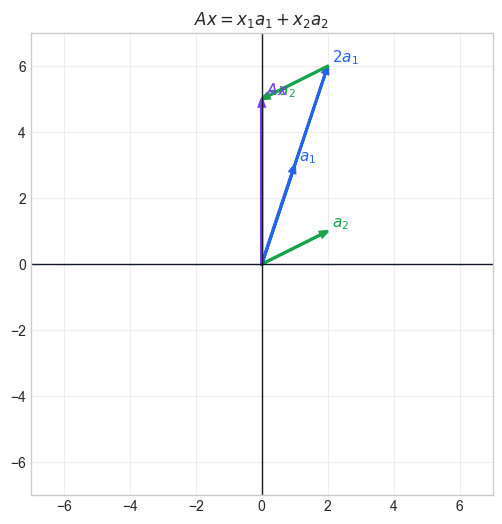

A @ x = [0. 5.]


In [106]:
A = np.array([[1, 2], [3, 1]], dtype=float)
x = np.array([2, -1], dtype=float)
col1, col2 = A[:, 0], A[:, 1]
y = A @ x
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=7, title=r"$Ax = x_1a_1 + x_2a_2$")
draw_vector(ax, col1, color=COLORS["blue"], label=r"$a_1$")
draw_vector(ax, col2, color=COLORS["green"], label=r"$a_2$")
draw_vector(ax, x[0] * col1, color=COLORS["blue"], label=r"$2a_1$")
draw_vector(ax, x[1] * col2, origin=x[0] * col1, color=COLORS["green"], label=r"$-a_2$")
draw_vector(ax, y, color=COLORS["purple"], label=r"$Ax$")
plt.show()
print("A @ x =", y)


**Graph explanation.** The output vector is assembled from scaled columns of the matrix. This is the most useful way to mentally read $A\mathbf{x}$.


## Block 12 - Linear transformations: matrices move space

**Concept.** A matrix can rotate, scale, shear, or reflect every point in a space.

**Notation.** $T(\mathbf{x})=\mathbf{A}\mathbf{x}$.

**Theory.** A transformation is linear if it preserves addition and scalar multiplication.

**Math example.** $\begin{bmatrix}1&1\\0&1\end{bmatrix}$ shears points horizontally.

**Best ML example.** Linear layers transform input features into representation space.

**Visualization.** A square grid is sheared by a matrix.


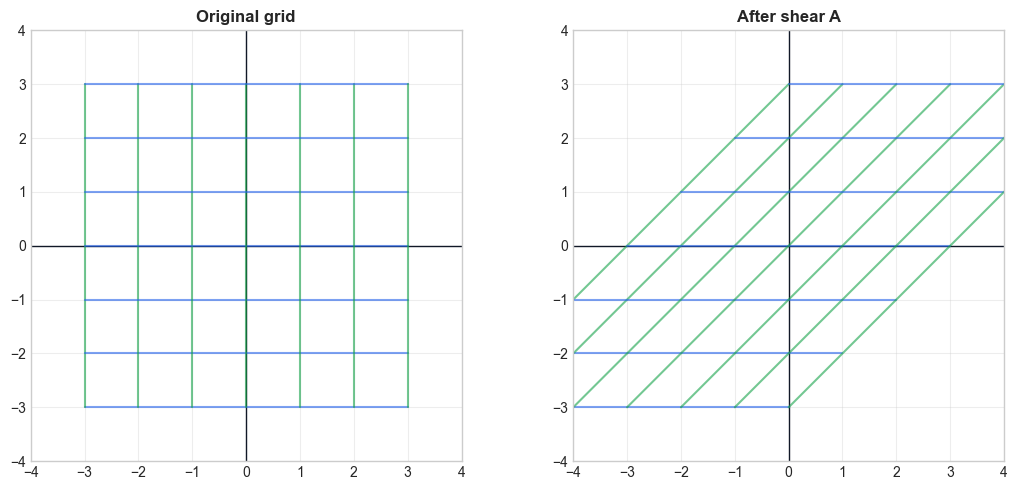

In [107]:
A = np.array([[1, 1.0], [0, 1]])
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, title, transform in [(axes[0], "Original grid", np.eye(2)), (axes[1], "After shear A", A)]:
    setup_2d_axis(ax, limit=4, title=title)
    for k in np.linspace(-3, 3, 7):
        pts1 = np.vstack([np.linspace(-3, 3, 100), np.full(100, k)])
        pts2 = np.vstack([np.full(100, k), np.linspace(-3, 3, 100)])
        q1, q2 = transform @ pts1, transform @ pts2
        ax.plot(q1[0], q1[1], color=COLORS["blue"], alpha=0.6)
        ax.plot(q2[0], q2[1], color=COLORS["green"], alpha=0.6)
plt.tight_layout()
plt.show()


**Graph explanation.** The heatmap treats each matrix entry as a colored cell. Rows represent samples, columns represent features, and the color intensity helps you quickly see which values are large or small.


## Block 13 - Special matrices and standard basis vectors

**Concept.** Some matrices appear everywhere: identity, zero, ones, and standard basis vectors.

**Notation.** $\mathbf{I}_n$, $\mathbf{0}_{m,n}$, $\mathbf{1}_{m,n}$, and $\mathbf{e}_i$.

**Theory.** $\mathbf{I}\mathbf{x}=\mathbf{x}$; $\mathbf{0}\mathbf{x}=\mathbf{0}$; $\mathbf{e}_i$ represents coordinate direction $i$.

**Math example.** $\mathbf{e}_2=[0,1,0]^T$ in $\mathbb{R}^3$.

**Best ML example.** One-hot encoding uses standard basis vectors to represent categories.

**Visualization.** These matrices have distinct visual patterns.


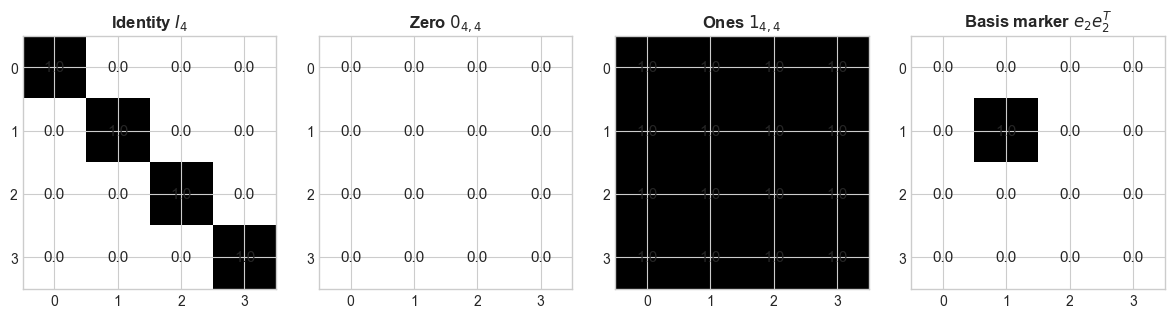

One-hot('green') = [0 1 0]


In [108]:
matrices = [np.eye(4), np.zeros((4, 4)), np.ones((4, 4)), np.diag([0, 1, 0, 0])]
titles = [r"Identity $I_4$", r"Zero $0_{4,4}$", r"Ones $1_{4,4}$", r"Basis marker $e_2e_2^T$"]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, M, title in zip(axes, matrices, titles):
    show_matrix(ax, M, title, cmap="Greys", vmin=0, vmax=1)
plt.tight_layout()
plt.show()
category = "green"
one_hot = {"red": np.array([1,0,0]), "green": np.array([0,1,0]), "blue": np.array([0,0,1])}
print(f"One-hot({category!r}) =", one_hot[category])


**Graph explanation.** The plot shows that vector coordinates are ordered. Swapping the same two numbers changes the endpoint and direction, which is why feature order must stay consistent in machine learning.


## Block 14 - Determinant: area scaling and orientation

**Concept.** The determinant measures how a square matrix scales area or volume.

**Notation.** $\det(\mathbf{A})$ or $|\mathbf{A}|$.

**Theory.** In 2D, $|\det(\mathbf{A})|$ is the area scale factor. A zero determinant collapses space and means no inverse exists.

**Math example.** $\det\begin{bmatrix}2&1\\0&1\end{bmatrix}=2$, so areas double.

**Best ML example.** Determinants appear in multivariate Gaussian densities and change-of-variables formulas.

**Visualization.** The unit square becomes a parallelogram whose area is $|\det(A)|$.


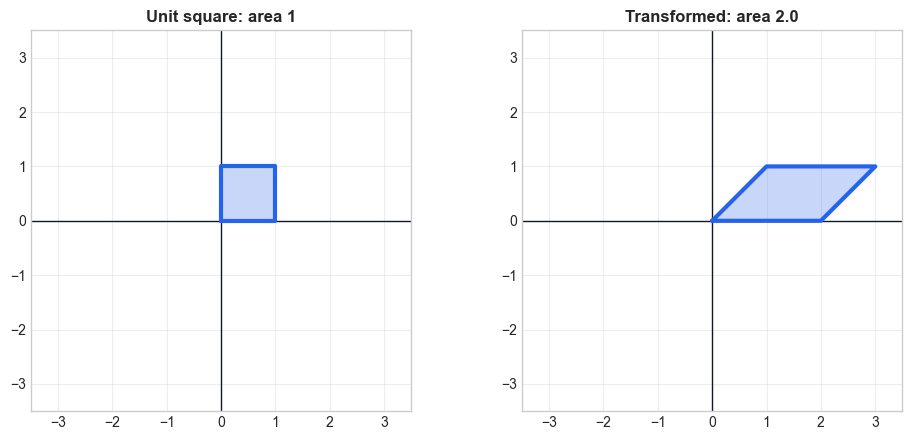

det(A) = 2.0


In [109]:
A = np.array([[2, 1], [0, 1]], dtype=float)
square = np.array([[0,0], [1,0], [1,1], [0,1], [0,0]], dtype=float)
transformed = square @ A.T
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, pts, title in [(axes[0], square, "Unit square: area 1"), (axes[1], transformed, fr"Transformed: area {abs(np.linalg.det(A)):.1f}")]:
    setup_2d_axis(ax, limit=3.5, title=title)
    ax.fill(pts[:,0], pts[:,1], color=COLORS["blue"], alpha=0.25)
    ax.plot(pts[:,0], pts[:,1], color=COLORS["blue"], linewidth=3)
plt.tight_layout()
plt.show()
print("det(A) =", np.linalg.det(A))


**Graph explanation.** The parallelogram shows how the matrix changes area. Its area compared with the original square is the absolute determinant.


## Block 15 - Inverse matrices: undoing a transformation

**Concept.** An inverse matrix reverses the action of a matrix.

**Notation.** $\mathbf{A}^{-1}$.

**Theory.** If $\mathbf{A}$ is invertible, then $\mathbf{A}^{-1}\mathbf{A}=\mathbf{I}$. A matrix is invertible only when its determinant is nonzero and its columns are independent.

**Math example.** If $\mathbf{y}=\mathbf{A}\mathbf{x}$, then $\mathbf{x}=\mathbf{A}^{-1}\mathbf{y}$.

**Best ML example.** Numerical ML code usually uses `np.linalg.solve` instead of explicitly computing inverse matrices.

**Visualization.** Transform a point, then apply the inverse to return home.


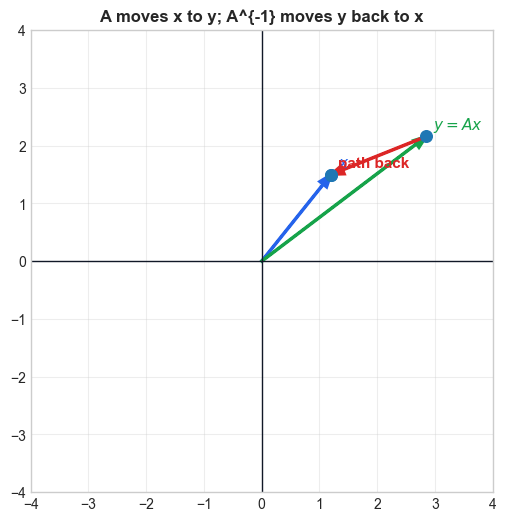

A_inv @ (A @ x) = [1.2 1.5]


In [110]:
A = np.array([[1.5, 0.7], [0.3, 1.2]])
A_inv = np.linalg.inv(A)
x = np.array([1.2, 1.5])
y = A @ x
x_back = A_inv @ y
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=4, title="A moves x to y; A^{-1} moves y back to x")
draw_vector(ax, x, color=COLORS["blue"], label=r"$x$")
draw_vector(ax, y, color=COLORS["green"], label=r"$y=Ax$")
draw_vector(ax, x_back - y, origin=y, color=COLORS["red"], label="path back")
ax.scatter([x[0], y[0], x_back[0]], [x[1], y[1], x_back[1]], s=70)
plt.show()
print("A_inv @ (A @ x) =", x_back)


**Graph explanation.** The heatmap treats each matrix entry as a colored cell. Rows represent samples, columns represent features, and the color intensity helps you quickly see which values are large or small.


## Block 16 - Linear systems: solving A x = b

**Concept.** A linear system asks which vector $\mathbf{x}$ maps to $\mathbf{b}$ under $\mathbf{A}$.

**Notation.** $\mathbf{A}\mathbf{x}=\mathbf{b}$.

**Theory.** A 2-equation, 2-unknown system often represents two lines. The solution is their intersection.

**Math example.** $x+y=3$ and $2x-y=0$ has solution $(1,2)$.

**Best ML example.** Normal equations for linear regression form a linear system: $\mathbf{X}^T\mathbf{X}\mathbf{w}=\mathbf{X}^T\mathbf{y}$.

**Visualization.** The solution is where both lines agree.


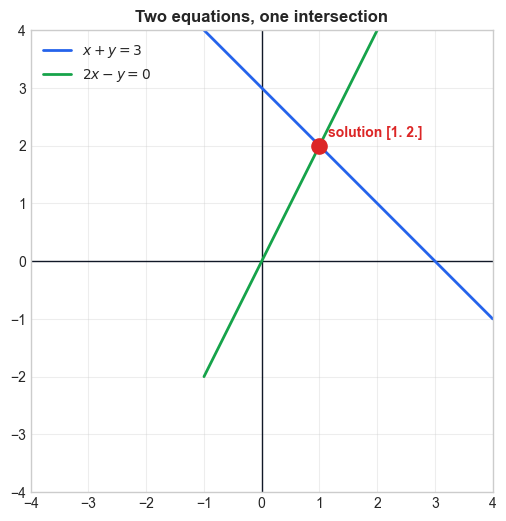

In [111]:
A = np.array([[1, 1], [2, -1]], dtype=float)
b = np.array([3, 0], dtype=float)
solution = np.linalg.solve(A, b)
xs = np.linspace(-1, 4, 200)
y1 = 3 - xs
y2 = 2 * xs
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=4, title="Two equations, one intersection")
ax.plot(xs, y1, label=r"$x+y=3$", color=COLORS["blue"], linewidth=2)
ax.plot(xs, y2, label=r"$2x-y=0$", color=COLORS["green"], linewidth=2)
ax.scatter(solution[0], solution[1], s=120, color=COLORS["red"], zorder=5)
ax.text(solution[0]+0.15, solution[1]+0.15, f"solution {solution}", color=COLORS["red"], weight="bold")
ax.legend()
plt.show()


**Graph explanation.** Each line is one equation. Their intersection is the point that satisfies both equations at the same time.


## Block 17 - Rank: independent directions in a matrix

**Concept.** Rank counts the number of independent columns or rows in a matrix.

**Notation.** $\operatorname{rank}(\mathbf{A})$.

**Theory.** Low rank means redundancy. A $2\times2$ rank-1 matrix collapses the plane onto a line.

**Math example.** $\begin{bmatrix}1&2\\2&4\end{bmatrix}$ has rank 1 because the second column is twice the first.

**Best ML example.** Low-rank structure powers compression, recommender systems, PCA, and matrix factorization.

**Visualization.** A full-rank transformation keeps a grid two-dimensional; rank one collapses it.


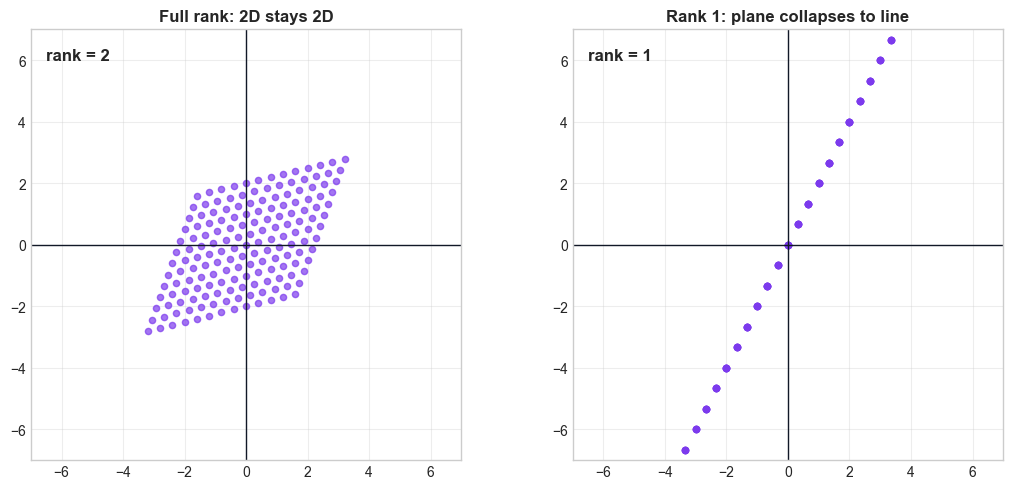

In [112]:
full = np.array([[1.2, 0.4], [0.3, 1.1]])
low = np.array([[1, 2], [2, 4]], dtype=float)
points = np.array([[x, y] for x in np.linspace(-2, 2, 13) for y in np.linspace(-2, 2, 13)]).T
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, M, title in [(axes[0], full, "Full rank: 2D stays 2D"), (axes[1], low, "Rank 1: plane collapses to line")]:
    setup_2d_axis(ax, limit=7, title=title)
    q = M @ points
    ax.scatter(q[0], q[1], s=20, color=COLORS["purple"], alpha=0.7)
    ax.text(-6.5, 6, f"rank = {np.linalg.matrix_rank(M)}", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()


**Graph explanation.** The full-rank matrix keeps points spread across a plane. The rank-one matrix squeezes all transformed points onto a line, revealing lost dimensions.


## Block 18 - Null space: directions that disappear

**Concept.** The null space contains every vector that a matrix maps to zero.

**Notation.** $\mathcal{N}(\mathbf{A})=\{\mathbf{x}:\mathbf{A}\mathbf{x}=\mathbf{0}\}$.

**Theory.** If a nonzero vector is in the null space, the matrix loses information and cannot be inverted.

**Math example.** For $\mathbf{A}=[1\ -1]$, every vector $[t,t]^T$ maps to 0.

**Best ML example.** Null spaces explain non-identifiability: different parameter vectors can produce identical predictions.

**Visualization.** Points on the line $x=y$ are sent to zero by $[1,-1]$.


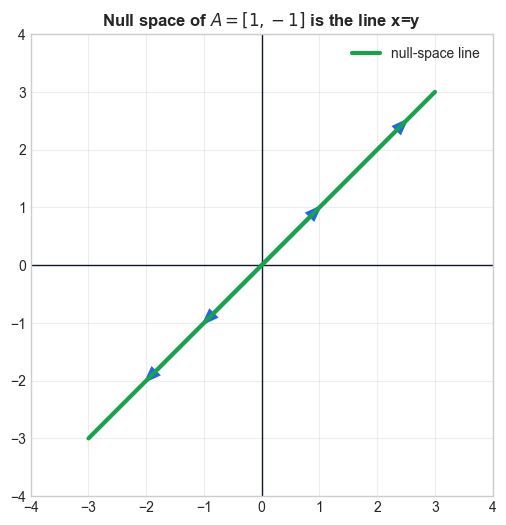

A @ [2, 2]^T = [0.]


In [113]:
A = np.array([[1, -1]], dtype=float)
ts = np.linspace(-3, 3, 100)
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=4, title=r"Null space of $A=[1,-1]$ is the line x=y")
ax.plot(ts, ts, color=COLORS["green"], linewidth=3, label="null-space line")
for t in [-2, -1, 1, 2.5]:
    draw_vector(ax, np.array([t, t]), color=COLORS["blue"])
ax.legend()
plt.show()
print("A @ [2, 2]^T =", A @ np.array([2, 2]))


**Graph explanation.** Every vector drawn on the green line maps to zero under the matrix. That line is the set of directions the transformation cannot distinguish.


## Block 19 - Orthogonality: right-angle independence

**Concept.** Orthogonal vectors meet at 90 degrees and have zero dot product.

**Notation.** $\mathbf{x}\perp\mathbf{y}$ means $\mathbf{x}^T\mathbf{y}=0$.

**Theory.** Orthonormal matrices preserve lengths and angles: $\mathbf{Q}^T\mathbf{Q}=\mathbf{I}$.

**Math example.** $[1,2]^T\cdot[2,-1]^T=2-2=0$.

**Best ML example.** Orthogonal directions appear in PCA, QR decomposition, and stable neural-network initialization.

**Visualization.** A rotation matrix moves points but preserves their distance from the origin.


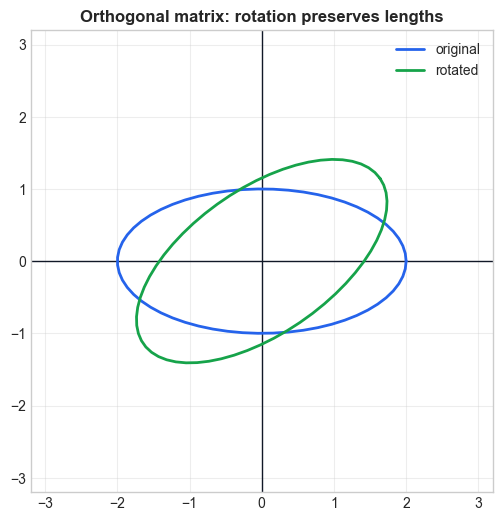

Q.T @ Q =
 [[1. 0.]
 [0. 1.]]


In [114]:
theta = np.deg2rad(35)
Q = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
angles = np.linspace(0, 2*np.pi, 60)
points = np.vstack([2*np.cos(angles), 1*np.sin(angles)])
rotated = Q @ points
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=3.2, title="Orthogonal matrix: rotation preserves lengths")
ax.plot(points[0], points[1], color=COLORS["blue"], linewidth=2, label="original")
ax.plot(rotated[0], rotated[1], color=COLORS["green"], linewidth=2, label="rotated")
ax.legend()
plt.show()
print("Q.T @ Q =\n", Q.T @ Q)


**Graph explanation.** The rotated curve keeps the same shape and size. This demonstrates that orthogonal transformations preserve lengths and angles.


## Block 20 - Eigenvectors and eigenvalues: directions that keep their line

**Concept.** An eigenvector is a direction that a matrix stretches or flips without rotating off its line.

**Notation.** $\mathbf{A}\mathbf{v}=\lambda\mathbf{v}$.

**Theory.** $\lambda$ is the eigenvalue; it tells the stretch factor along eigenvector $\mathbf{v}$.

**Math example.** If $\mathbf{A}=\begin{bmatrix}3&0\\0&1\end{bmatrix}$, then $[1,0]^T$ is an eigenvector with eigenvalue 3.

**Best ML example.** PCA uses eigenvectors of the covariance matrix to find principal directions of variation.

**Visualization.** Eigenvectors remain on the same line after transformation.


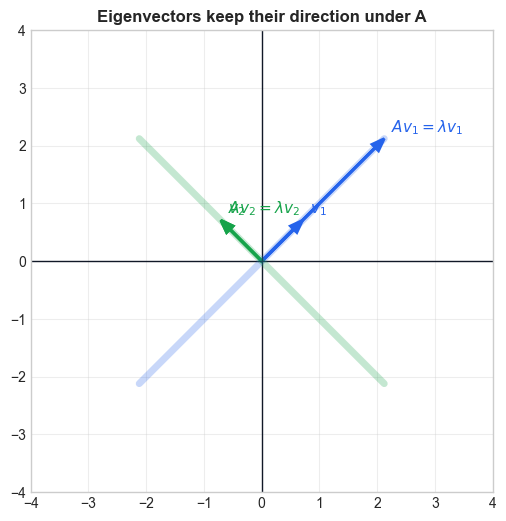

eigenvalues = [3. 1.]
eigenvectors =
 [[ 0.707 -0.707]
 [ 0.707  0.707]]


In [115]:
A = np.array([[2, 1], [1, 2]], dtype=float)
vals, vecs = np.linalg.eig(A)
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=4, title="Eigenvectors keep their direction under A")
for i, color in enumerate([COLORS["blue"], COLORS["green"]]):
    v = vecs[:, i]
    Av = A @ v
    line = np.outer(np.linspace(-3, 3, 20), v)
    ax.plot(line[:,0], line[:,1], color=color, alpha=0.25, linewidth=5)
    draw_vector(ax, v, color=color, label=fr"$v_{i+1}$")
    draw_vector(ax, Av, color=color, label=fr"$Av_{i+1}=\lambda v_{i+1}$", width=0.008)
plt.show()
print("eigenvalues =", vals)
print("eigenvectors =\n", vecs)


**Graph explanation.** The plot shows that vector coordinates are ordered. Swapping the same two numbers changes the endpoint and direction, which is why feature order must stay consistent in machine learning.


## Block 21 - Quadratic forms: geometry of curvature

**Concept.** A quadratic form turns a vector into a scalar using a matrix.

**Notation.** $q(\mathbf{x})=\mathbf{x}^T\mathbf{A}\mathbf{x}$.

**Theory.** If $\mathbf{A}$ is positive definite, the quadratic form is a bowl: $q(\mathbf{x})>0$ for every nonzero $\mathbf{x}$.

**Math example.** $[x,y]\begin{bmatrix}3&0\\0&1\end{bmatrix}[x,y]^T=3x^2+y^2$.

**Best ML example.** Hessian matrices describe the curvature of loss functions near minima.

**Visualization.** Contours of a positive definite quadratic form are ellipses.


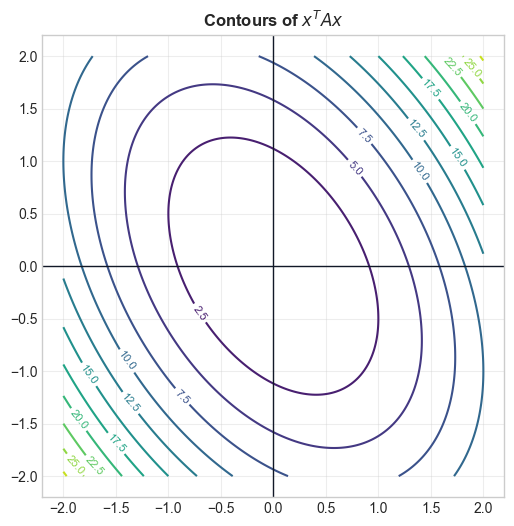

eigenvalues of A = [3.618 1.382]


In [116]:
A = np.array([[3, 1], [1, 2]], dtype=float)
x = np.linspace(-2, 2, 220)
y = np.linspace(-2, 2, 220)
X, Y = np.meshgrid(x, y)
Z = A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2
fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contour(X, Y, Z, levels=12, cmap="viridis")
ax.clabel(cs, inline=True, fontsize=8)
setup_2d_axis(ax, limit=2.2, title=r"Contours of $x^T A x$")
plt.show()
print("eigenvalues of A =", np.linalg.eigvals(A))


**Graph explanation.** The contour lines are level sets of the quadratic form. Tighter spacing means steeper curvature in that direction.


## Block 22 - Singular Value Decomposition: rotate, stretch, rotate

**Concept.** SVD decomposes any matrix into three interpretable pieces.

**Notation.** $\mathbf{A}=\mathbf{U}\mathbf{\Sigma}\mathbf{V}^T$.

**Theory.** $\mathbf{V}^T$ rotates input space, $\mathbf{\Sigma}$ stretches axes, and $\mathbf{U}$ rotates output space.

**Math example.** Singular values tell how much the matrix stretches the strongest directions.

**Best ML example.** SVD powers dimensionality reduction, denoising, recommender systems, and low-rank compression.

**Visualization.** The unit circle becomes an ellipse; singular vectors reveal stretch axes.


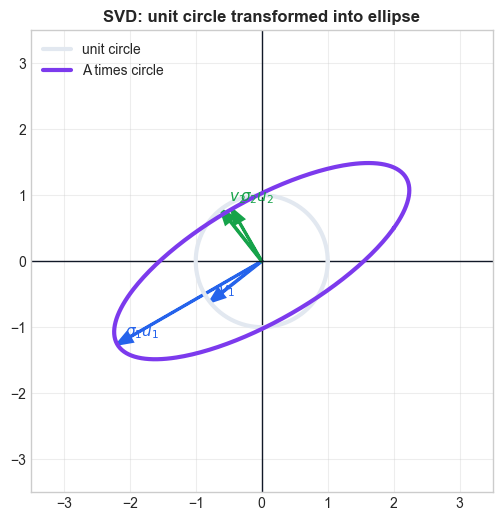

singular values = [2.526 0.911]


In [117]:
A = np.array([[2.0, 1.0], [0.5, 1.4]])
U, s, Vt = np.linalg.svd(A)
t = np.linspace(0, 2*np.pi, 300)
circle = np.vstack([np.cos(t), np.sin(t)])
ellipse = A @ circle
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=3.5, title="SVD: unit circle transformed into ellipse")
ax.plot(circle[0], circle[1], color=COLORS["light"], linewidth=3, label="unit circle")
ax.plot(ellipse[0], ellipse[1], color=COLORS["purple"], linewidth=3, label="A times circle")
for i, color in enumerate([COLORS["blue"], COLORS["green"]]):
    right = Vt.T[:, i]
    left_scaled = U[:, i] * s[i]
    draw_vector(ax, right, color=color, label=fr"$v_{i+1}$")
    draw_vector(ax, left_scaled, color=color, label=fr"$\sigma_{i+1}u_{i+1}$", width=0.008)
ax.legend(loc="upper left")
plt.show()
print("singular values =", s)


**Graph explanation.** The unit circle becomes an ellipse after the matrix transformation. The long and short axes reveal the strongest and weakest stretch directions.


## Block 23 - Least squares: best fit when exact solution is impossible

**Concept.** Least squares chooses parameters that minimize squared residuals.

**Notation.** $\min_{\mathbf{w}}\|\mathbf{X}\mathbf{w}-\mathbf{y}\|_2^2$.

**Theory.** The fitted predictions $\hat{\mathbf{y}}=\mathbf{X}\hat{\mathbf{w}}$ are the projection of $\mathbf{y}$ onto the column space of $\mathbf{X}$.

**Math example.** For $y=w_0+w_1x$, least squares finds the intercept and slope that minimize vertical squared errors.

**Best ML example.** Linear regression is least squares with data matrix $\mathbf{X}$ and target vector $\mathbf{y}$.

**Visualization.** The fitted line is the best linear summary of noisy points.


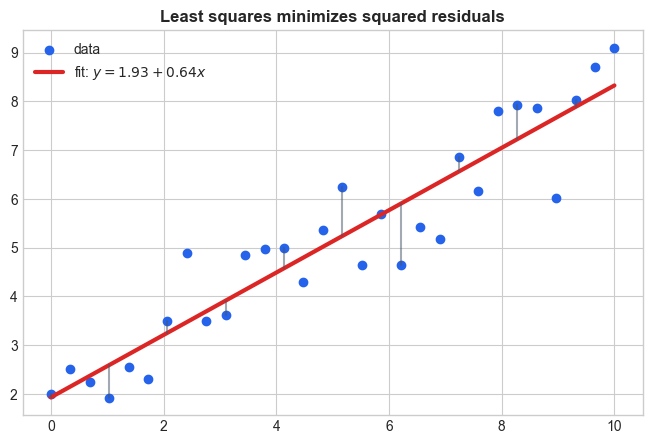

w_hat = [1.928 0.64 ]


In [118]:
rng = np.random.default_rng(7)
x = np.linspace(0, 10, 30)
y = 2.0 + 0.7*x + rng.normal(0, 0.9, size=x.size)
X = np.column_stack([np.ones_like(x), x])
w_hat = np.linalg.lstsq(X, y, rcond=None)[0]
y_hat = X @ w_hat
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color=COLORS["blue"], label="data")
ax.plot(x, y_hat, color=COLORS["red"], linewidth=3, label=fr"fit: $y={w_hat[0]:.2f}+{w_hat[1]:.2f}x$")
for xi, yi, yh in zip(x[::3], y[::3], y_hat[::3]):
    ax.plot([xi, xi], [yi, yh], color=COLORS["gray"], alpha=0.5)
ax.set_title("Least squares minimizes squared residuals", fontsize=12, weight="bold")
ax.legend()
plt.show()
print("w_hat =", w_hat)


**Graph explanation.** The red line is the best linear fit. The gray vertical segments are residuals, and least squares chooses the line that minimizes their squared lengths.


## Block 24 - Covariance and PCA: directions of maximum variation

**Concept.** Covariance measures how variables move together. PCA rotates data into directions of greatest variance.

**Notation.** For centered data, $\mathbf{C}=\frac{1}{m-1}\mathbf{X}^T\mathbf{X}$.

**Theory.** Principal components are eigenvectors of the covariance matrix. Larger eigenvalues mean more variance along that direction.

**Math example.** If two features increase together, their covariance is positive.

**Best ML example.** PCA reduces dimensionality while preserving as much variance as possible.

**Visualization.** Principal axes sit along the long and short directions of a data cloud.


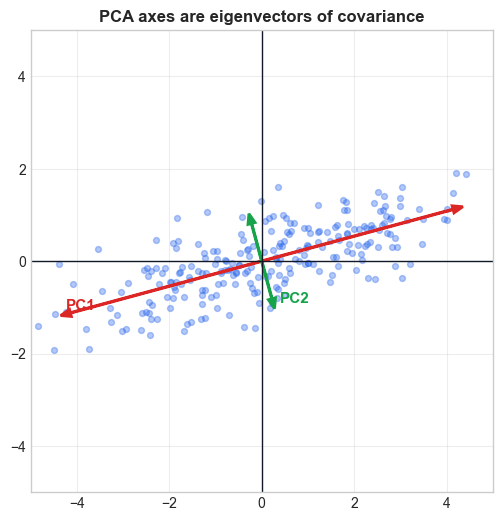

covariance matrix =
 [[4.757 1.211]
 [1.211 0.611]]
explained variance = [5.084 0.283]


In [119]:
rng = np.random.default_rng(12)
base = rng.normal(size=(250, 2))
M = np.array([[2.2, 0.9], [0.3, 0.7]])
X = base @ M.T
X_centered = X - X.mean(axis=0)
C = np.cov(X_centered, rowvar=False)
vals, vecs = np.linalg.eigh(C)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=5, title="PCA axes are eigenvectors of covariance")
ax.scatter(X_centered[:,0], X_centered[:,1], s=18, alpha=0.35, color=COLORS["blue"])
for i, color in enumerate([COLORS["red"], COLORS["green"]]):
    axis = vecs[:, i] * np.sqrt(vals[i]) * 2
    draw_vector(ax, axis, color=color, label=fr"PC{i+1}")
    draw_vector(ax, -axis, color=color)
plt.show()
print("covariance matrix =\n", C)
print("explained variance =", vals)


**Graph explanation.** The point cloud shows correlated data. The principal component arrows point along the directions of maximum and minimum variance.


## Block 25 - Condition number: when small errors become large

**Concept.** The condition number measures numerical sensitivity.

**Notation.** $\kappa(\mathbf{A})=\|\mathbf{A}\|\|\mathbf{A}^{-1}\|$.

**Theory.** A large condition number means tiny changes in $\mathbf{b}$ can cause large changes in the solution of $\mathbf{A}\mathbf{x}=\mathbf{b}$.

**Math example.** Nearly parallel equations create unstable intersections.

**Best ML example.** Poorly scaled features make optimization and regression unstable; standardization often improves conditioning.

**Visualization.** A tiny perturbation in $\mathbf{b}$ moves the solution noticeably for an ill-conditioned system.


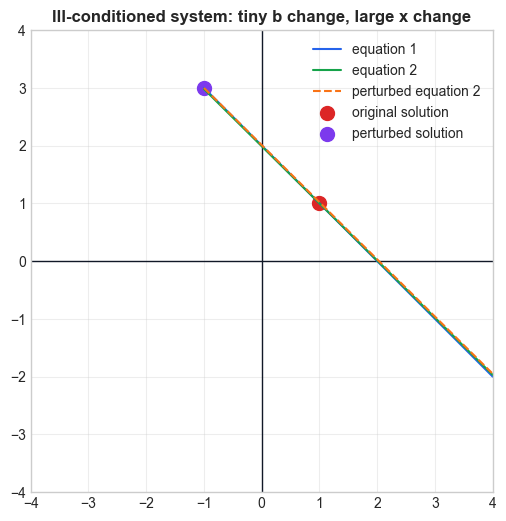

condition number = 402.0075124842952
original solution = [1. 1.]
perturbed solution = [-1.  3.]


In [120]:
A = np.array([[1, 1], [1, 1.01]], dtype=float)
b = np.array([2, 2.01])
b_perturbed = b + np.array([0.0, 0.02])
x1 = np.linalg.solve(A, b)
x2 = np.linalg.solve(A, b_perturbed)
fig, ax = plt.subplots(figsize=(7, 6))
setup_2d_axis(ax, limit=4, title="Ill-conditioned system: tiny b change, large x change")
xs = np.linspace(-1, 4, 300)
ax.plot(xs, b[0]-xs, color=COLORS["blue"], label="equation 1")
ax.plot(xs, (b[1]-xs)/1.01, color=COLORS["green"], label="equation 2")
ax.plot(xs, (b_perturbed[1]-xs)/1.01, color=COLORS["orange"], linestyle="--", label="perturbed equation 2")
ax.scatter(*x1, s=100, color=COLORS["red"], label="original solution")
ax.scatter(*x2, s=100, color=COLORS["purple"], label="perturbed solution")
ax.legend()
plt.show()
print("condition number =", np.linalg.cond(A))
print("original solution =", x1)
print("perturbed solution =", x2)


**Graph explanation.** The nearly parallel lines make the system sensitive. A tiny change in one equation moves the intersection a lot, which is the practical meaning of ill-conditioning.


## Block 26 - Broadcasting and vectorization: NumPy that matches the math

**Concept.** Broadcasting lets NumPy combine arrays of compatible shapes without manual loops.

**Notation.** Centering data is $\mathbf{X}_{centered}=\mathbf{X}-\boldsymbol{\mu}$, where $\boldsymbol{\mu}$ is a row vector of feature means.

**Theory.** NumPy aligns dimensions from the right. Shapes are compatible when each aligned dimension is equal or one of them is 1.

**Math example.** A $4\times3$ data matrix minus a $1\times3$ mean vector subtracts each feature mean from every row.

**Best ML example.** Standardization, batch normalization, distance matrices, and vectorized training all depend on broadcasting.

**Visualization.** Feature centering shifts every column to mean zero.


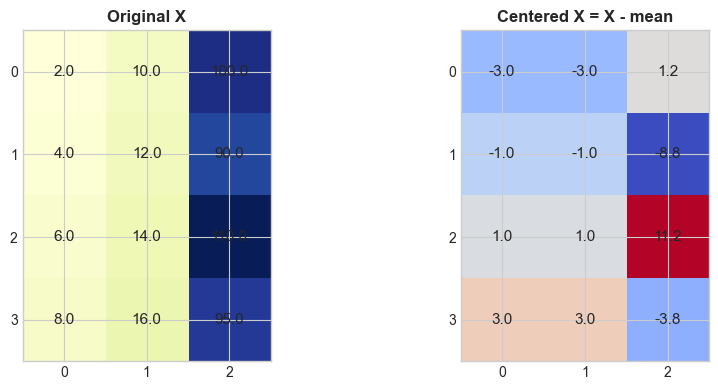

X shape: (4, 3)
mean shape: (1, 3)
column means after centering: [0. 0. 0.]


In [121]:
X = np.array([[2, 10, 100], [4, 12, 90], [6, 14, 110], [8, 16, 95]], dtype=float)
mu = X.mean(axis=0, keepdims=True)
X_centered = X - mu
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
show_matrix(axes[0], X, "Original X", cmap="YlGnBu")
show_matrix(axes[1], X_centered, "Centered X = X - mean", cmap="coolwarm")
plt.tight_layout()
plt.show()
print("X shape:", X.shape)
print("mean shape:", mu.shape)
print("column means after centering:", X_centered.mean(axis=0))


**Graph explanation.** The second heatmap shows each feature column after subtracting its mean. Broadcasting applies the same mean vector to every row.


## Block 27 - Ordered tuples: sequence matters

**Concept.** A tuple is an ordered collection. The same values in a different order describe a different object.

**Notation.** $(a,b,c)$ or $(x_1,x_2,\ldots,x_n)$.

**Theory.** Tuples are ordered, while sets are not. This matters because vectors and feature rows are ordered.

**Math example.** $(3,1,4)\ne(1,3,4)$.

**Best ML example.** A feature row like `(age, income, score)` changes meaning if the order is shuffled.

**Visualization.** The same values are shown in two different coordinate orders.


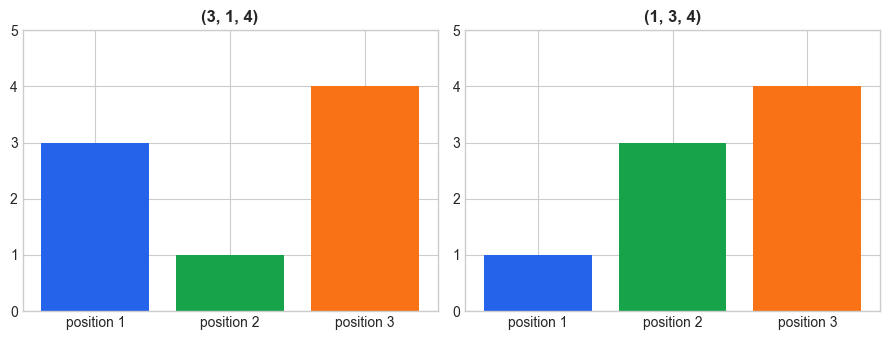

In [122]:
tuple_a = (3, 1, 4)
tuple_b = (1, 3, 4)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, values, title in zip(axes, [tuple_a, tuple_b], ["(3, 1, 4)", "(1, 3, 4)"]):
    ax.bar(range(len(values)), values, color=[COLORS["blue"], COLORS["green"], COLORS["orange"]])
    ax.set_xticks(range(len(values)), ["position 1", "position 2", "position 3"])
    ax.set_ylim(0, 5)
    ax.set_title(title, weight="bold")
plt.tight_layout()
plt.show()


**Graph explanation.** The two bar charts contain the same values, but the positions are different. This reinforces that order carries meaning.


## Block 28 - Column stacking: building matrices from vectors

**Concept.** A matrix can be built by placing vectors side by side as columns.

**Notation.** $\mathbf{A}=[\mathbf{a}_1\ \mathbf{a}_2\ \cdots\ \mathbf{a}_n]$.

**Theory.** Matrix columns define the directions available for linear combinations.

**Math example.** If $\mathbf{a}_1=[1,3]^T$ and $\mathbf{a}_2=[2,4]^T$, then $\mathbf{A}=\begin{bmatrix}1&2\\3&4\end{bmatrix}$.

**Best ML example.** Design matrices are often viewed as feature columns.

**Visualization.** Two vectors become the two columns of a matrix.


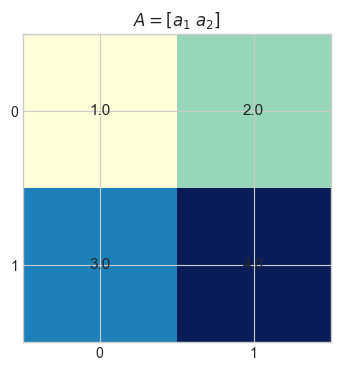

A =
 [[1 2]
 [3 4]]


In [123]:
a1 = np.array([1, 3])
a2 = np.array([2, 4])
A = np.column_stack([a1, a2])
fig, ax = plt.subplots(figsize=(4.5, 4))
show_matrix(ax, A, r"$A=[a_1\ a_2]$", cmap="YlGnBu")
plt.show()
print("A =\n", A)


**Graph explanation.** The plot shows that vector coordinates are ordered. Swapping the same two numbers changes the endpoint and direction, which is why feature order must stay consistent in machine learning.


## Block 29 - Sets: unordered collections

**Concept.** A set is a collection where order and repeated entries do not matter.

**Notation.** $A=\{1,2,3\}$, $x\in A$, $x\notin A$.

**Theory.** Sets are useful for describing spaces, samples, labels, and conditions.

**Math example.** $\{1,2,2,3\}=\{1,2,3\}$.

**Best ML example.** A classification label set might be $\mathcal{Y}=\{\text{cat},\text{dog},\text{bird}\}$.

**Visualization.** Membership is shown as points inside or outside a region.


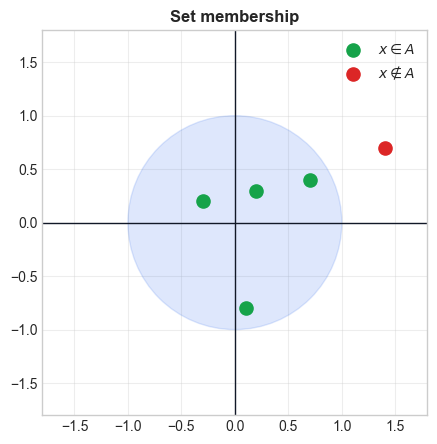

In [124]:
points = np.array([[0.2, 0.3], [0.7, 0.4], [1.4, 0.7], [-0.3, 0.2], [0.1, -0.8]])
inside = np.linalg.norm(points, axis=1) <= 1
fig, ax = plt.subplots(figsize=(5, 5))
circle = plt.Circle((0, 0), 1, color=COLORS["blue"], alpha=0.15)
ax.add_patch(circle)
ax.scatter(points[inside,0], points[inside,1], color=COLORS["green"], s=90, label=r"$x\in A$")
ax.scatter(points[~inside,0], points[~inside,1], color=COLORS["red"], s=90, label=r"$x\notin A$")
setup_2d_axis(ax, limit=1.8, title="Set membership")
ax.legend()
plt.show()


**Graph explanation.** Points inside the circle belong to the set; points outside do not. The plot makes membership visually concrete.


## Block 30 - Universal quantifier: for all

**Concept.** The universal quantifier states that a property holds for every element in a domain.

**Notation.** $\forall x\in S,\ P(x)$ means "for every $x$ in $S$, property $P$ is true."

**Theory.** One counterexample is enough to disprove a universal statement.

**Math example.** $\forall x\in\{1,2,3\}, x>0$ is true.

**Best ML example.** A constraint may require $\forall i,\ p_i\ge0$ for all class probabilities.

**Visualization.** Every bar satisfies the nonnegative condition.


In [125]:
values = np.array([0.2, 0.7, 0.1, 0.4])
ok = values >= 0
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(len(values)), values, color=[COLORS["green"] if v else COLORS["red"] for v in ok])
ax.axhline(0, color="black")
ax.set_title(r"$\forall i,\ p_i\ge 0$", weight="bold")
plt.show()
print("All nonnegative?", np.all(ok))


ValueError: 
\forall i,\ p_i\ge 0
               ^
ParseFatalException: Unknown symbol: \ge, found '\'  (at char 15), (line:1, col:16)

<Figure size 600x350 with 1 Axes>

All nonnegative? True


**Graph explanation.** Every bar is checked against the same condition. The statement is true only because all values satisfy it.


## Block 31 - Existential quantifier: there exists

**Concept.** The existential quantifier states that at least one element satisfies a property.

**Notation.** $\exists x\in S: P(x)$ means "there exists an $x$ in $S$ such that $P$ is true."

**Theory.** One example is enough to prove an existential statement.

**Math example.** $\exists x\in\{1,2,3\}:x^2=4$ is true because $x=2$.

**Best ML example.** Early stopping may ask whether there exists an epoch with validation loss below a threshold.

**Visualization.** At least one loss value crosses the target line.


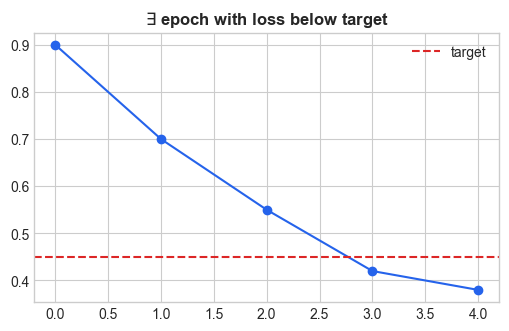

Exists below threshold? True


In [126]:
loss = np.array([0.9, 0.7, 0.55, 0.42, 0.38])
threshold = 0.45
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(loss, marker="o", color=COLORS["blue"])
ax.axhline(threshold, color=COLORS["red"], linestyle="--", label="target")
ax.set_title(r"$\exists$ epoch with loss below target", weight="bold")
ax.legend()
plt.show()
print("Exists below threshold?", np.any(loss < threshold))


**Graph explanation.** Only one point needs to cross the threshold to make an existence statement true. The plot highlights that at least one epoch succeeds.


## Block 32 - Definition symbols: := and =:

**Concept.** Definition symbols introduce a new name for an expression.

**Notation.** $a:=b$ means "define $a$ to be $b$"; $a=:b$ means "define $b$ to be $a$."

**Theory.** A definition is not a discovery; it assigns meaning.

**Math example.** $\sigma(x):=\frac{1}{1+e^{-x}}$ defines the sigmoid function.

**Best ML example.** Papers often define losses, models, and distributions using `:=`.

**Visualization.** A formula is named and then reused.


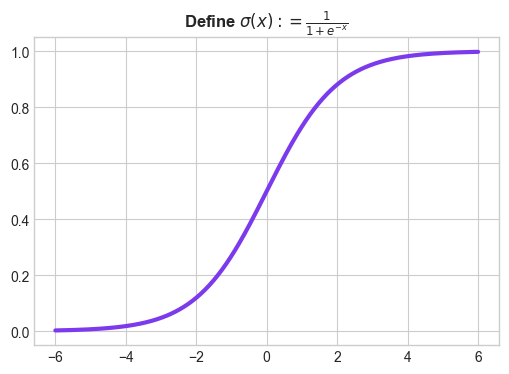

In [127]:
z = np.linspace(-6, 6, 300)
sigmoid = 1 / (1 + np.exp(-z))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z, sigmoid, color=COLORS["purple"], linewidth=3)
ax.set_title(r"Define $\sigma(x):=\frac{1}{1+e^{-x}}$", weight="bold")
ax.set_ylim(-0.05, 1.05)
plt.show()


**Graph explanation.** The curve shows a formula after it has been given a name. Once defined, the symbol can be reused without rewriting the full expression.


## Block 33 - Logical equivalence: if and only if

**Concept.** Logical equivalence means two statements always have the same truth value.

**Notation.** $P\Leftrightarrow Q$ means "$P$ if and only if $Q$."

**Theory.** Equivalence requires both implications: $P\Rightarrow Q$ and $Q\Rightarrow P$.

**Math example.** For real $x$, $x^2=0\Leftrightarrow x=0$.

**Best ML example.** A theorem may state that a matrix is invertible iff its determinant is nonzero.

**Visualization.** The truth table marks rows where $P$ and $Q$ match.


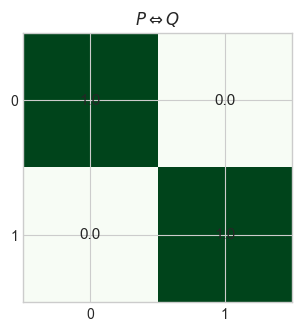

In [128]:
P = np.array([False, False, True, True])
Q = np.array([False, True, False, True])
equiv = P == Q
fig, ax = plt.subplots(figsize=(5, 3.5))
show_matrix(ax, equiv.reshape(2, 2).astype(int), r"$P\Leftrightarrow Q$", cmap="Greens", vmin=0, vmax=1)
plt.show()


**Graph explanation.** Cells marked 1 are cases where the two statements match. Equivalence requires matching truth values in every case.


## Block 34 - Implication: if P then Q

**Concept.** Implication says that whenever $P$ is true, $Q$ must be true.

**Notation.** $P\Rightarrow Q$.

**Theory.** The only false case is $P$ true and $Q$ false.

**Math example.** If $x>2$, then $x^2>4$.

**Best ML example.** If a vector is one-hot, then its entries sum to 1.

**Visualization.** The truth table highlights the only violation.


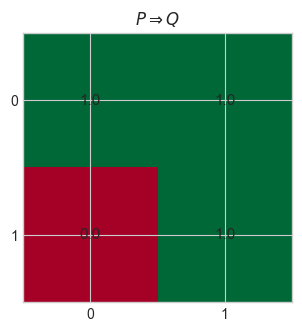

In [129]:
P = np.array([False, False, True, True])
Q = np.array([False, True, False, True])
imp = (~P) | Q
fig, ax = plt.subplots(figsize=(5, 3.5))
show_matrix(ax, imp.reshape(2, 2).astype(int), r"$P\Rightarrow Q$", cmap="RdYlGn", vmin=0, vmax=1)
plt.show()


**Graph explanation.** The truth table marks when an implication holds. The only failure happens when the premise is true but the conclusion is false.


## Block 35 - Dimension: counting degrees of freedom

**Concept.** Dimension counts how many independent coordinates are needed to describe a space.

**Notation.** $\dim(V)$.

**Theory.** A line has dimension 1, a plane has dimension 2, and $\mathbb{R}^n$ has dimension $n$.

**Math example.** $\dim(\mathbb{R}^3)=3$.

**Best ML example.** Dimensionality reduction maps high-dimensional data into a lower-dimensional representation.

**Visualization.** Data near a line is approximately one-dimensional.


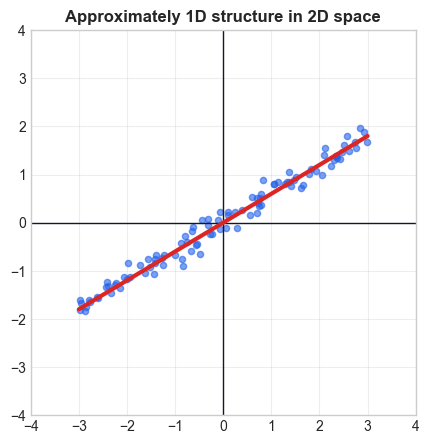

In [130]:
t = np.linspace(-3, 3, 100)
line = np.column_stack([t, 0.6*t])
noise = np.random.default_rng(0).normal(scale=0.15, size=line.shape)
data = line + noise
fig, ax = plt.subplots(figsize=(6, 5))
setup_2d_axis(ax, limit=4, title="Approximately 1D structure in 2D space")
ax.scatter(data[:,0], data[:,1], s=20, alpha=0.6, color=COLORS["blue"])
ax.plot(line[:,0], line[:,1], color=COLORS["red"], linewidth=3)
plt.show()


**Graph explanation.** The points live in 2D coordinates but mostly follow one line. This is why low-dimensional structure can exist inside a higher-dimensional space.


## Block 36 - Image of a map: reachable outputs

**Concept.** The image of a linear map is the set of all outputs it can produce.

**Notation.** $\operatorname{Im}(\Phi)=\{\Phi(\mathbf{x}):\mathbf{x}\in V\}$.

**Theory.** For a matrix $A$, the image is the column space of $A$.

**Math example.** If $A=\begin{bmatrix}1&2\\2&4\end{bmatrix}$, its image is a line.

**Best ML example.** Model predictions live in the image of the design matrix.

**Visualization.** Inputs in a plane are mapped to a one-dimensional output line.


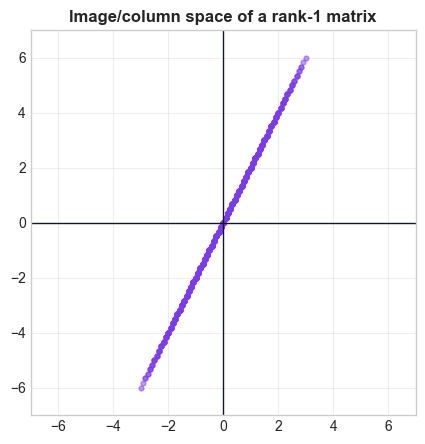

In [131]:
A = np.array([[1, 2], [2, 4]], dtype=float)
pts = np.array([[x, y] for x in np.linspace(-1, 1, 25) for y in np.linspace(-1, 1, 25)]).T
out = A @ pts
fig, ax = plt.subplots(figsize=(6, 5))
setup_2d_axis(ax, limit=7, title="Image/column space of a rank-1 matrix")
ax.scatter(out[0], out[1], s=12, alpha=0.5, color=COLORS["purple"])
plt.show()


**Graph explanation.** The transformed outputs lie on a line. This line is the image or column space of the rank-one matrix.


## Block 37 - Trace: sum of diagonal entries

**Concept.** The trace is the sum of a square matrix's diagonal entries.

**Notation.** $\operatorname{tr}(A)$.

**Theory.** The trace equals the sum of eigenvalues, counted with multiplicity.

**Math example.** $\operatorname{tr}\begin{bmatrix}2&5\\1&3\end{bmatrix}=2+3=5$.

**Best ML example.** Trace appears in matrix calculus, covariance objectives, and PCA variance.

**Visualization.** The diagonal entries are highlighted.


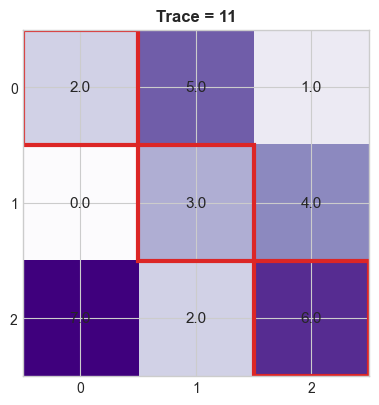

In [132]:
A = np.array([[2, 5, 1], [0, 3, 4], [7, 2, 6]], dtype=float)
fig, ax = plt.subplots(figsize=(5, 4.5))
show_matrix(ax, A, fr"Trace = {np.trace(A):.0f}", cmap="Purples")
for i in range(A.shape[0]):
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor=COLORS["red"], linewidth=3))
plt.show()


**Graph explanation.** The highlighted cell connects math indexing to Python indexing. Math uses row 2, column 3 for $a_{23}$, while NumPy uses `A[1, 2]` because Python starts counting at zero.


## Block 38 - Absolute value: distance from zero

**Concept.** Absolute value gives the nonnegative magnitude of a scalar.

**Notation.** $|x|$.

**Theory.** $|x|=x$ if $x\ge0$ and $|x|=-x$ if $x<0$.

**Math example.** $|-3|=3$.

**Best ML example.** Mean absolute error uses absolute values: $\frac1n\sum_i|y_i-\hat y_i|$.

**Visualization.** Negative values are folded upward.


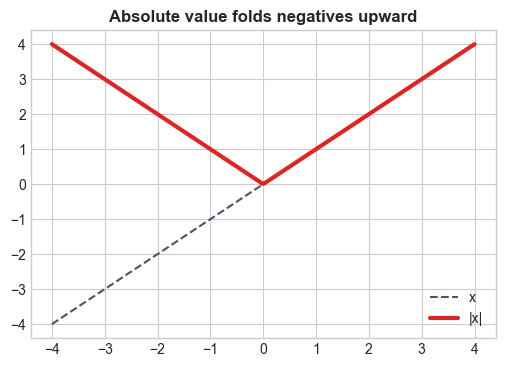

In [133]:
x = np.linspace(-4, 4, 300)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, x, color=COLORS["gray"], linestyle="--", label="x")
ax.plot(x, np.abs(x), color=COLORS["red"], linewidth=3, label="|x|")
ax.set_title("Absolute value folds negatives upward", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The dashed line is the original value and the solid curve is its magnitude. Negative values are reflected upward.


## Block 39 - Parameter vector theta

**Concept.** A parameter vector stores the learnable numbers of a model.

**Notation.** $\boldsymbol{\theta}=[\theta_0,\theta_1,\ldots,\theta_d]^T$.

**Theory.** Training changes parameters to reduce a loss function.

**Math example.** A line has $\boldsymbol{\theta}=[b,w]^T$ for $\hat y=b+wx$.

**Best ML example.** Neural networks may contain millions or billions of parameters.

**Visualization.** Predictions change as parameters change.


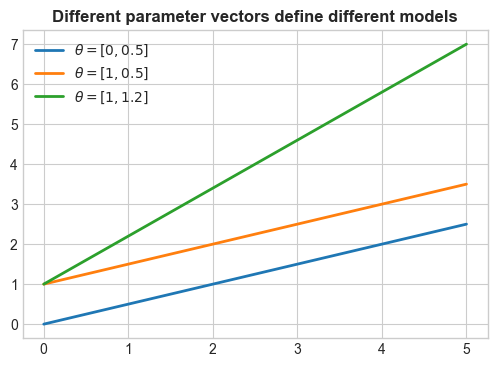

In [134]:
x = np.linspace(0, 5, 100)
params = [(0, 0.5), (1, 0.5), (1, 1.2)]
fig, ax = plt.subplots(figsize=(6, 4))
for b, w in params:
    ax.plot(x, b + w*x, linewidth=2, label=fr"$\theta=[{b},{w}]$")
ax.set_title("Different parameter vectors define different models", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** Each line comes from a different parameter vector. Changing the intercept or slope changes the model's predictions.


## Block 40 - Partial derivative: one variable at a time

**Concept.** A partial derivative measures how a multivariable function changes with one variable while holding others fixed.

**Notation.** $\frac{\partial f}{\partial x}$.

**Theory.** For $f(x,y)=x^2+3y$, $\frac{\partial f}{\partial x}=2x$.

**Math example.** At $(2,1)$, $\frac{\partial f}{\partial x}=4$.

**Best ML example.** Backpropagation computes partial derivatives of loss with respect to each parameter.

**Visualization.** A slice of the surface shows change along one variable.


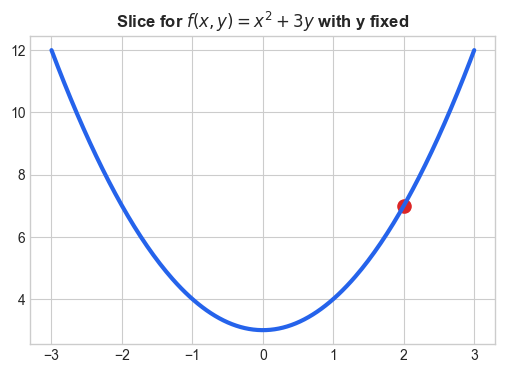

In [135]:
x = np.linspace(-3, 3, 200)
y_fixed = 1
f_slice = x**2 + 3*y_fixed
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, f_slice, color=COLORS["blue"], linewidth=3)
ax.scatter([2], [2**2 + 3*y_fixed], color=COLORS["red"], s=90)
ax.set_title(r"Slice for $f(x,y)=x^2+3y$ with y fixed", weight="bold")
plt.show()


**Graph explanation.** The curve is a slice through a multivariable surface while one variable is held fixed. This shows what a partial derivative measures.


## Block 41 - Total derivative: change along a path

**Concept.** A total derivative measures how a function changes when its input changes along a single path.

**Notation.** $\frac{df}{dt}$ or $\frac{df}{dx}$.

**Theory.** If $f(x(t),y(t))$, the chain rule combines all variable changes.

**Math example.** If $f=x^2+y^2$, $x=t$, $y=2t$, then $df/dt=10t$.

**Best ML example.** Computational graphs use total derivatives through chained operations.

**Visualization.** A path through input space produces a one-dimensional curve of function values.


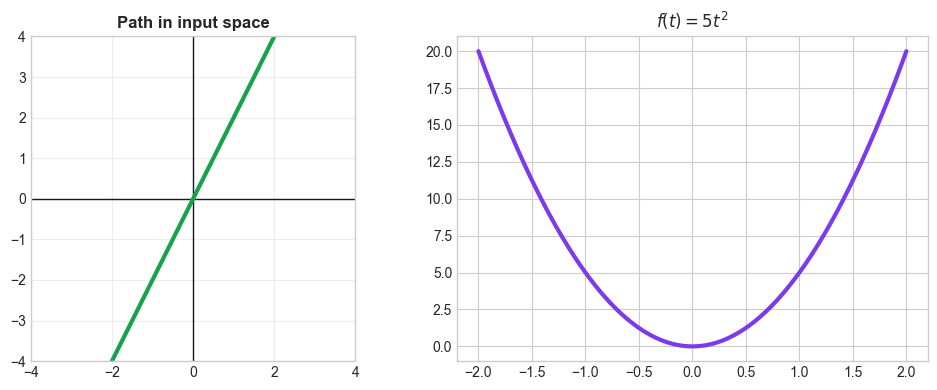

In [136]:
t = np.linspace(-2, 2, 200)
x = t
y = 2*t
f = x**2 + y**2
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
setup_2d_axis(axes[0], limit=4, title="Path in input space")
axes[0].plot(x, y, color=COLORS["green"], linewidth=3)
axes[1].plot(t, f, color=COLORS["purple"], linewidth=3)
axes[1].set_title(r"$f(t)=5t^2$", weight="bold")
plt.tight_layout()
plt.show()


**Graph explanation.** The first plot shows a path through input space, and the second shows the function value along that path. Total derivatives track change along the path.


## Block 42 - Gradient: direction of steepest increase

**Concept.** The gradient is the vector of partial derivatives.

**Notation.** $\nabla f(\mathbf{x})$.

**Theory.** The gradient points in the direction where the function increases fastest.

**Math example.** If $f(x,y)=x^2+y^2$, then $\nabla f=[2x,2y]^T$.

**Best ML example.** Gradient descent moves opposite the gradient to reduce loss.

**Visualization.** Gradient arrows point outward from a bowl.


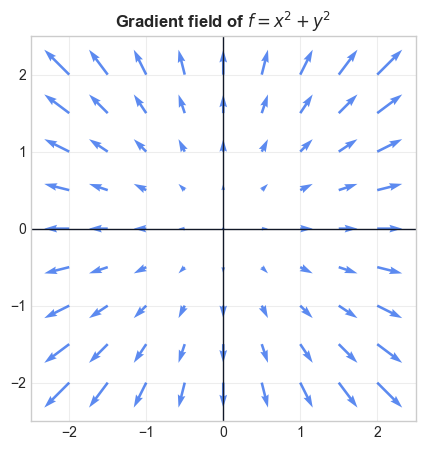

In [137]:
grid = np.linspace(-2, 2, 9)
X, Y = np.meshgrid(grid, grid)
U, V = 2*X, 2*Y
fig, ax = plt.subplots(figsize=(6, 5))
setup_2d_axis(ax, limit=2.5, title=r"Gradient field of $f=x^2+y^2$")
ax.quiver(X, Y, U, V, color=COLORS["blue"], alpha=0.75)
plt.show()


**Graph explanation.** The arrows show the direction of steepest increase. For a bowl-shaped function, gradients point outward from the minimum.


## Block 43 - Lagrangian: optimization with constraints

**Concept.** A Lagrangian combines an objective and constraints into one expression.

**Notation.** $\mathcal{L}(x,\lambda)=f(x)+\lambda g(x)$.

**Theory.** At constrained optima, gradients of the objective and constraint align.

**Math example.** Minimize $x^2+y^2$ subject to $x+y=1$.

**Best ML example.** Constrained optimization appears in SVMs, regularization, and probabilistic normalization.

**Visualization.** The closest point on a constraint line to the origin is the optimum.


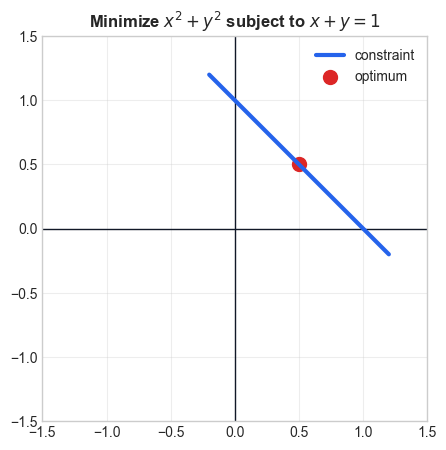

In [138]:
xs = np.linspace(-0.2, 1.2, 200)
ys = 1 - xs
opt = np.array([0.5, 0.5])
fig, ax = plt.subplots(figsize=(6, 5))
setup_2d_axis(ax, limit=1.5, title=r"Minimize $x^2+y^2$ subject to $x+y=1$")
ax.plot(xs, ys, color=COLORS["blue"], linewidth=3, label="constraint")
ax.scatter(*opt, color=COLORS["red"], s=100, label="optimum")
ax.legend()
plt.show()


**Graph explanation.** The constraint line limits where solutions may live. The optimum is the feasible point closest to the objective's preferred location.


## Block 44 - Negative log-likelihood: turning probability into loss

**Concept.** Negative log-likelihood penalizes models that assign low probability to observed data.

**Notation.** $\mathrm{NLL}=-\log\mathcal{L}$.

**Theory.** Maximizing likelihood is equivalent to minimizing negative log-likelihood.

**Math example.** If a correct class has probability $0.9$, loss is $-\log(0.9)$.

**Best ML example.** Classification models are often trained by minimizing NLL/cross-entropy.

**Visualization.** Loss increases sharply when predicted probability approaches zero.


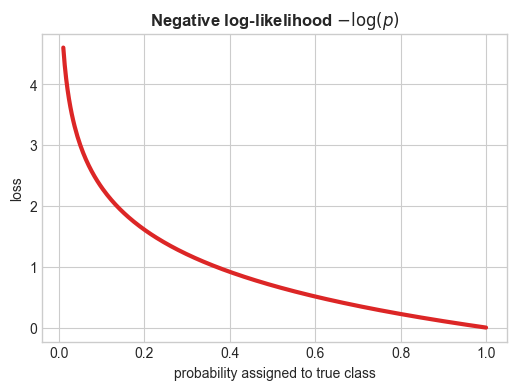

In [139]:
p = np.linspace(0.01, 1, 300)
loss = -np.log(p)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p, loss, color=COLORS["red"], linewidth=3)
ax.set_title(r"Negative log-likelihood $-\log(p)$", weight="bold")
ax.set_xlabel("probability assigned to true class")
ax.set_ylabel("loss")
plt.show()


**Graph explanation.** The curve rises sharply when the model assigns low probability to the true outcome. This is why confident wrong predictions are punished heavily.


## Block 45 - Binomial coefficient: n choose k

**Concept.** The binomial coefficient counts how many ways to choose $k$ items from $n$.

**Notation.** $\binom{n}{k}$.

**Theory.** $\binom{n}{k}=\frac{n!}{k!(n-k)!}$.

**Math example.** $\binom{5}{2}=10$.

**Best ML example.** It appears in binomial probabilities, sampling, and combinatorial model counts.

**Visualization.** The row of Pascal's triangle for $n=5$.


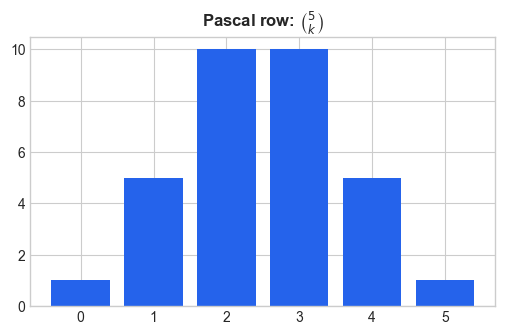

[1, 5, 10, 10, 5, 1]


In [140]:
import math
n = 5
values = [math.comb(n, k) for k in range(n+1)]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(n+1), values, color=COLORS["blue"])
ax.set_xticks(range(n+1))
ax.set_title(r"Pascal row: $\binom{5}{k}$", weight="bold")
plt.show()
print(values)


**Graph explanation.** The bars show how many ways each number of successes can occur. Middle counts often have more combinations than extreme counts.


## Block 46 - Expectation: long-run average

**Concept.** Expectation is the probability-weighted average value of a random variable.

**Notation.** $\mathbb{E}[X]$.

**Theory.** For discrete $X$, $\mathbb{E}[X]=\sum_x xP(X=x)$.

**Math example.** A fair die has expectation $(1+2+3+4+5+6)/6=3.5$.

**Best ML example.** Expected loss is the ideal objective minimized by learning algorithms.

**Visualization.** The expected value is the balance point of a distribution.


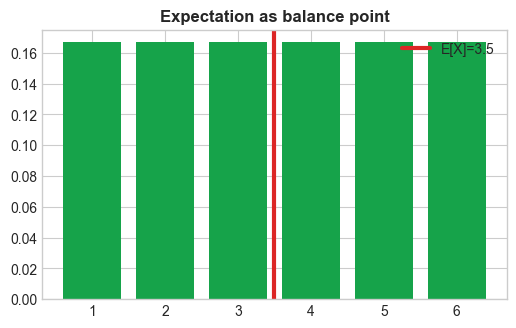

In [141]:
values = np.arange(1, 7)
probs = np.ones(6) / 6
expected = np.sum(values * probs)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(values, probs, color=COLORS["green"])
ax.axvline(expected, color=COLORS["red"], linewidth=3, label=f"E[X]={expected}")
ax.legend()
ax.set_title("Expectation as balance point", weight="bold")
plt.show()


**Graph explanation.** The vertical line is the balance point of the distribution. It shows the probability-weighted average outcome.


## Block 47 - Variance: spread around the mean

**Concept.** Variance measures how far values spread around their mean.

**Notation.** $\mathbb{V}[X]$ or $\operatorname{Var}(X)$.

**Theory.** $\operatorname{Var}(X)=\mathbb{E}[(X-\mathbb{E}[X])^2]$.

**Math example.** Values close to the mean have low variance; values far away have high variance.

**Best ML example.** Variance explains noise, uncertainty, overfitting, and PCA.

**Visualization.** Two samples with different spread.


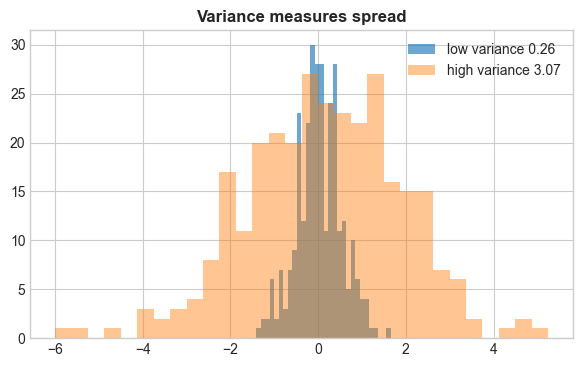

In [142]:
rng = np.random.default_rng(3)
a = rng.normal(0, 0.5, 300)
b = rng.normal(0, 1.8, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(a, bins=30, alpha=0.65, label=f"low variance {np.var(a):.2f}")
ax.hist(b, bins=30, alpha=0.45, label=f"high variance {np.var(b):.2f}")
ax.set_title("Variance measures spread", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The wider histogram has larger variance. More spread around the mean means more uncertainty or variability.


## Block 48 - Conditional independence

**Concept.** Conditional independence means two variables become independent after knowing a third variable.

**Notation.** $X\perp\!\!\!\perp Y\mid Z$.

**Theory.** $P(X,Y\mid Z)=P(X\mid Z)P(Y\mid Z)$.

**Math example.** Shoe size and reading ability may be associated in children, but become less related after conditioning on age.

**Best ML example.** Graphical models and Bayesian networks rely on conditional independence assumptions.

**Visualization.** Two variables share a common cause, so conditioning matters.


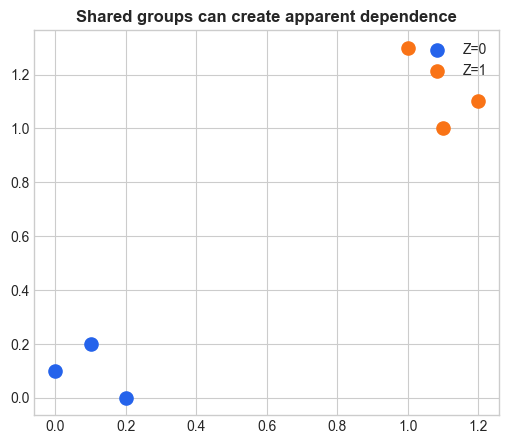

In [143]:
Z = np.array([0, 0, 0, 1, 1, 1])
X = np.array([0.1, 0.2, 0.0, 1.1, 1.0, 1.2])
Y = np.array([0.2, 0.0, 0.1, 1.0, 1.3, 1.1])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[Z==0], Y[Z==0], color=COLORS["blue"], s=90, label="Z=0")
ax.scatter(X[Z==1], Y[Z==1], color=COLORS["orange"], s=90, label="Z=1")
ax.set_title("Shared groups can create apparent dependence", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The groups show how a shared condition can explain apparent dependence. Conditioning separates relationships that may look mixed together globally.


## Block 49 - Distribution notation

**Concept.** Distribution notation states the probability law a random variable follows.

**Notation.** $X\sim p$ means "$X$ is distributed according to $p$."

**Theory.** The distribution determines probabilities, expectation, variance, and samples.

**Math example.** $X\sim\mathcal{N}(0,1)$ means a standard normal random variable.

**Best ML example.** Probabilistic models assume data or noise distributions.

**Visualization.** Samples form the shape of their distribution.


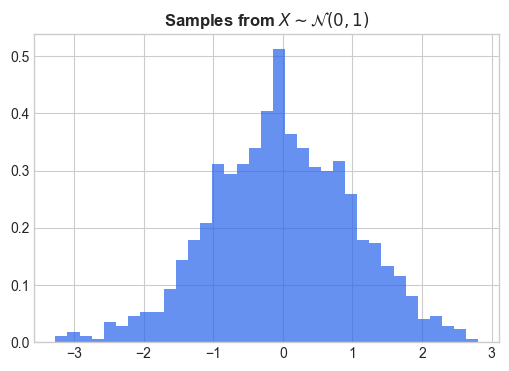

In [144]:
rng = np.random.default_rng(4)
samples = rng.normal(0, 1, 1000)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(samples, bins=35, density=True, color=COLORS["blue"], alpha=0.7)
ax.set_title(r"Samples from $X\sim\mathcal{N}(0,1)$", weight="bold")
plt.show()


**Graph explanation.** The histogram is formed from many samples drawn from the stated distribution. Its shape approximates the probability law.


## Block 50 - Multivariate Gaussian

**Concept.** A multivariate Gaussian models several continuous variables jointly.

**Notation.** $\mathcal{N}(\boldsymbol{\mu},\boldsymbol{\Sigma})$.

**Theory.** $\boldsymbol{\mu}$ controls the center; $\boldsymbol{\Sigma}$ controls spread and correlation.

**Math example.** A 2D Gaussian can have elliptical contours.

**Best ML example.** Gaussian assumptions appear in naive Bayes, Kalman filters, Gaussian mixtures, and latent variable models.

**Visualization.** Correlated Gaussian samples form an ellipse-like cloud.


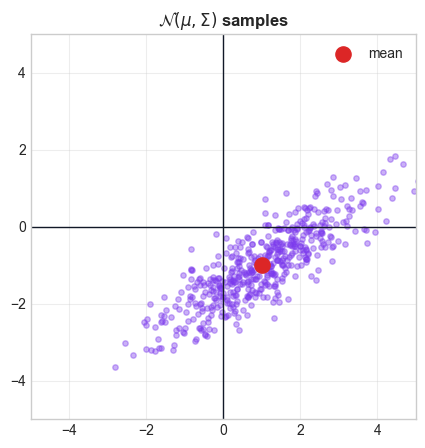

In [145]:
rng = np.random.default_rng(5)
mu = np.array([1, -1])
Sigma = np.array([[2.0, 1.2], [1.2, 1.0]])
X = rng.multivariate_normal(mu, Sigma, size=500)
fig, ax = plt.subplots(figsize=(6, 5))
setup_2d_axis(ax, limit=5, title=r"$\mathcal{N}(\mu,\Sigma)$ samples")
ax.scatter(X[:,0], X[:,1], s=15, alpha=0.4, color=COLORS["purple"])
ax.scatter(*mu, color=COLORS["red"], s=120, label="mean")
ax.legend()
plt.show()


**Graph explanation.** The cloud's center is controlled by the mean, and its elliptical spread is controlled by the covariance matrix.


## Block 51 - Bernoulli distribution

**Concept.** A Bernoulli random variable models one yes/no trial.

**Notation.** $X\sim\operatorname{Ber}(\mu)$.

**Theory.** $P(X=1)=\mu$ and $P(X=0)=1-\mu$.

**Math example.** A biased coin with heads probability 0.7 is Bernoulli(0.7).

**Best ML example.** Binary classification outputs often parameterize a Bernoulli distribution.

**Visualization.** Probability mass is placed on 0 and 1.


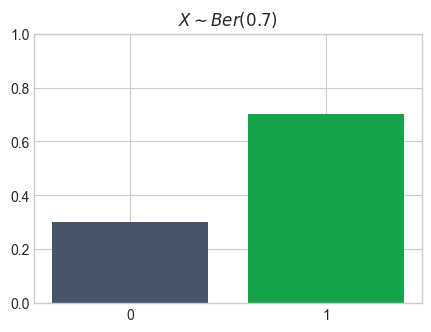

In [146]:
mu = 0.7
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar([0, 1], [1-mu, mu], color=[COLORS["gray"], COLORS["green"]])
ax.set_xticks([0, 1])
ax.set_ylim(0, 1)
ax.set_title(r"$X\sim Ber(0.7)$", weight="bold")
plt.show()


**Graph explanation.** The two bars are the only possible outcomes: 0 and 1. Their heights are the probabilities of failure and success.


## Block 52 - Binomial distribution

**Concept.** A binomial random variable counts successes in repeated Bernoulli trials.

**Notation.** $X\sim\operatorname{Bin}(N,\mu)$.

**Theory.** $P(X=k)=\binom{N}{k}\mu^k(1-\mu)^{N-k}$.

**Math example.** Number of heads in 10 coin flips.

**Best ML example.** It models counts of positive outcomes in fixed-size batches.

**Visualization.** The probability mass function across possible success counts.


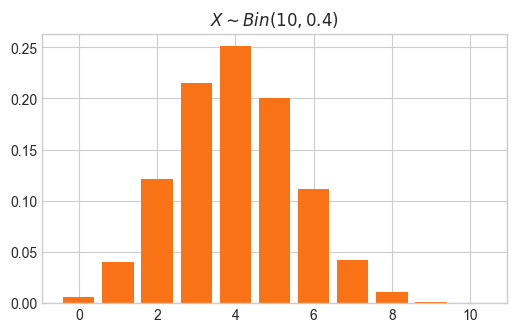

In [147]:
import math
N, mu = 10, 0.4
ks = np.arange(N+1)
pmf = np.array([math.comb(N, k) * mu**k * (1-mu)**(N-k) for k in ks])
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(ks, pmf, color=COLORS["orange"])
ax.set_title(r"$X\sim Bin(10,0.4)$", weight="bold")
plt.show()


**Graph explanation.** Each bar gives the probability of seeing exactly k successes. The whole chart sums to one.


## Block 53 - Beta distribution

**Concept.** The Beta distribution models uncertainty over a probability between 0 and 1.

**Notation.** $X\sim\operatorname{Beta}(\alpha,\beta)$.

**Theory.** Larger $\alpha$ favors values near 1; larger $\beta$ favors values near 0.

**Math example.** Beta(2,5) places more mass near smaller probabilities.

**Best ML example.** Beta distributions are conjugate priors for Bernoulli probabilities.

**Visualization.** Several Beta-like shapes are plotted using a normalized grid.


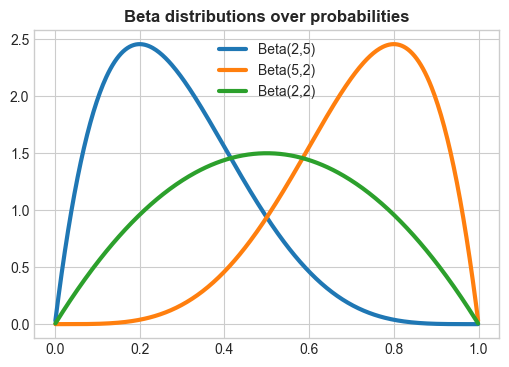

In [148]:
import math
x = np.linspace(0.001, 0.999, 400)
pairs = [(2, 5), (5, 2), (2, 2)]
fig, ax = plt.subplots(figsize=(6, 4))
for a, b in pairs:
    B = math.gamma(a) * math.gamma(b) / math.gamma(a + b)
    y = x**(a-1) * (1-x)**(b-1) / B
    ax.plot(x, y, linewidth=3, label=fr"Beta({a},{b})")
ax.set_title("Beta distributions over probabilities", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** Each curve is a different belief over a probability value. The shape changes as alpha and beta change.


## Block 54 - Argmin and argmax

**Concept.** Argmin and argmax return the input location where a function is smallest or largest.

**Notation.** $\arg\min_x f(x)$ and $\arg\max_x f(x)$.

**Theory.** The minimum value is $f(x^*)$; the argmin is $x^*$ itself.

**Math example.** For $f(x)=(x-2)^2$, $\arg\min_x f(x)=2$.

**Best ML example.** Training seeks $\arg\min_\theta \mathcal{L}(\theta)$.

**Visualization.** The argmin is marked on a loss curve.


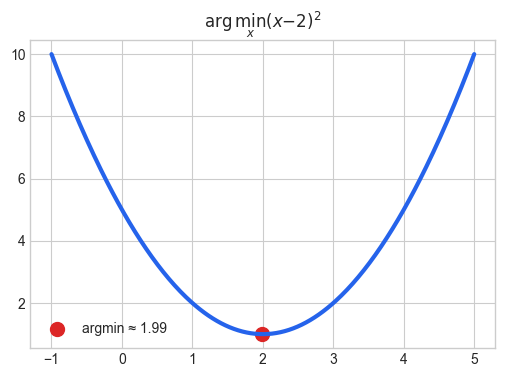

In [149]:
x = np.linspace(-1, 5, 300)
loss = (x - 2)**2 + 1
idx = np.argmin(loss)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, loss, color=COLORS["blue"], linewidth=3)
ax.scatter(x[idx], loss[idx], color=COLORS["red"], s=100, label=fr"argmin ≈ {x[idx]:.2f}")
ax.set_title(r"$\arg\min_x (x-2)^2$", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The highlighted point is not the minimum value itself; it is the input where the function reaches that minimum.


## Block 55 - Indicator function

**Concept.** An indicator function returns 1 when a condition is true and 0 otherwise.

**Notation.** $\mathbf{1}\{\text{condition}\}$.

**Theory.** Indicators convert logical conditions into numbers.

**Math example.** $\mathbf{1}\{x>0\}=1$ for positive $x$, otherwise 0.

**Best ML example.** Accuracy averages indicators of correct predictions.

**Visualization.** A step function turns a condition into 0/1 values.


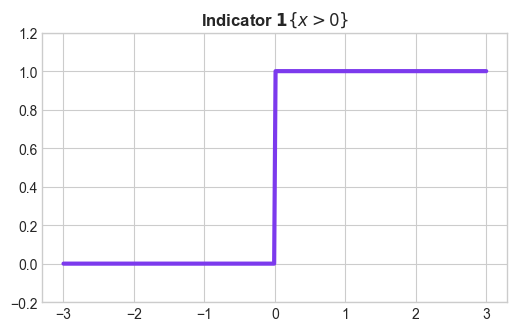

In [150]:
x = np.linspace(-3, 3, 300)
y = (x > 0).astype(int)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(x, y, color=COLORS["purple"], linewidth=3)
ax.set_ylim(-0.2, 1.2)
ax.set_title(r"Indicator $\mathbf{1}\{x>0\}$", weight="bold")
plt.show()


**Graph explanation.** The step curve converts a condition into numbers. False becomes 0 and true becomes 1.


## Block 56 - Softmax

**Concept.** Softmax converts a vector of scores into probabilities that sum to 1.

**Notation.** $\operatorname{softmax}(\mathbf{z})_i=\frac{e^{z_i}}{\sum_j e^{z_j}}$.

**Theory.** Larger scores receive larger probabilities, but all outputs remain positive and normalized.

**Math example.** Scores $[1,2,4]$ become class probabilities.

**Best ML example.** Multiclass classifiers often end with softmax.

**Visualization.** Scores become normalized probabilities.


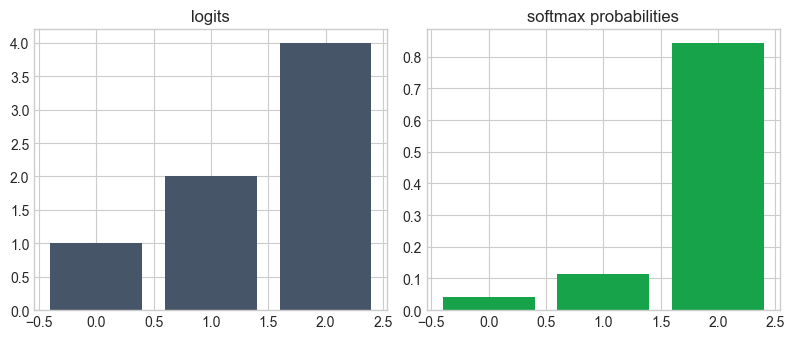

sum = 1.0


In [151]:
z = np.array([1.0, 2.0, 4.0])
exp_z = np.exp(z - z.max())
p = exp_z / exp_z.sum()
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].bar(range(3), z, color=COLORS["gray"])
axes[0].set_title("logits")
axes[1].bar(range(3), p, color=COLORS["green"])
axes[1].set_title("softmax probabilities")
plt.tight_layout()
plt.show()
print("sum =", p.sum())


**Graph explanation.** The left chart shows raw logits, and the right chart shows normalized probabilities. The largest logit receives the largest probability.


## Block 57 - Sigmoid

**Concept.** Sigmoid squashes any real number into the interval $(0,1)$.

**Notation.** $\sigma(x)=\frac{1}{1+e^{-x}}$.

**Theory.** Sigmoid is monotonic and centered at $\sigma(0)=0.5$.

**Math example.** $\sigma(0)=0.5$.

**Best ML example.** Binary classifiers use sigmoid to model probability of class 1.

**Visualization.** The S-shaped sigmoid curve.


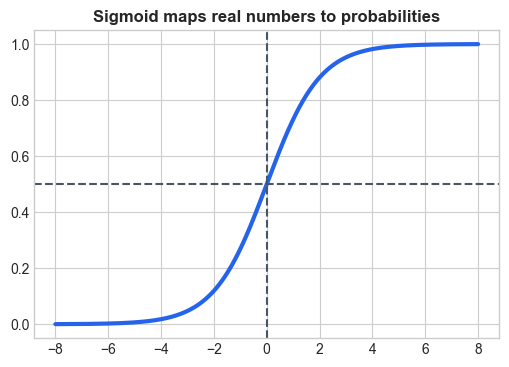

In [152]:
x = np.linspace(-8, 8, 400)
y = 1 / (1 + np.exp(-x))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, color=COLORS["blue"], linewidth=3)
ax.axhline(0.5, color=COLORS["gray"], linestyle="--")
ax.axvline(0, color=COLORS["gray"], linestyle="--")
ax.set_title("Sigmoid maps real numbers to probabilities", weight="bold")
plt.show()


**Graph explanation.** The S-curve maps any real-valued score into a probability-like value between 0 and 1.


## Block 58 - Cross-entropy

**Concept.** Cross-entropy measures how well predicted probabilities match target probabilities.

**Notation.** $H(p,q)=-\sum_i p_i\log q_i$.

**Theory.** For one-hot targets, cross-entropy is the negative log probability assigned to the correct class.

**Math example.** If the true class probability is predicted as 0.8, loss is $-\log(0.8)$.

**Best ML example.** Cross-entropy is the standard loss for classification.

**Visualization.** Loss decreases as probability assigned to the true class increases.


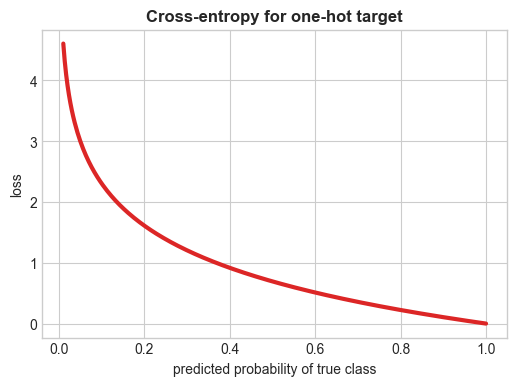

In [153]:
q_true = np.linspace(0.01, 1, 300)
ce = -np.log(q_true)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(q_true, ce, color=COLORS["red"], linewidth=3)
ax.set_title("Cross-entropy for one-hot target", weight="bold")
ax.set_xlabel("predicted probability of true class")
ax.set_ylabel("loss")
plt.show()


**Graph explanation.** The loss becomes small when the true class receives high probability and becomes large when that probability is low.


## Block 59 - KL divergence

**Concept.** KL divergence measures how much one probability distribution differs from another.

**Notation.** $D_{\mathrm{KL}}(p\|q)=\sum_i p_i\log\frac{p_i}{q_i}$.

**Theory.** KL is nonnegative but not symmetric.

**Math example.** $D_{\mathrm{KL}}(p\|p)=0$.

**Best ML example.** KL divergence appears in variational inference, VAEs, and policy optimization.

**Visualization.** Two categorical distributions are compared side by side.


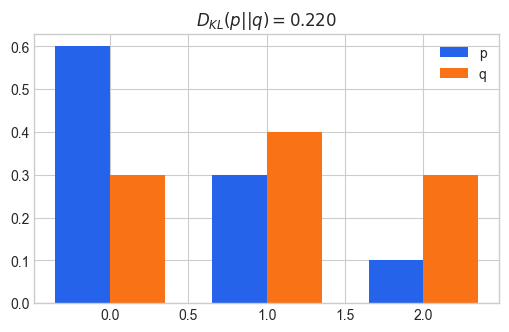

In [154]:
p = np.array([0.6, 0.3, 0.1])
q = np.array([0.3, 0.4, 0.3])
kl = np.sum(p * np.log(p / q))
fig, ax = plt.subplots(figsize=(6, 3.5))
w = 0.35
idx = np.arange(3)
ax.bar(idx - w/2, p, width=w, label="p", color=COLORS["blue"])
ax.bar(idx + w/2, q, width=w, label="q", color=COLORS["orange"])
ax.set_title(fr"$D_{{KL}}(p||q)={kl:.3f}$", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The two bar groups compare distributions. KL divergence grows when probability mass is placed differently in p and q.


## Block 60 - Entropy

**Concept.** Entropy measures uncertainty in a distribution.

**Notation.** $H(X)=-\sum_x p(x)\log p(x)$.

**Theory.** Entropy is higher when outcomes are more evenly spread.

**Math example.** A fair coin has more entropy than a heavily biased coin.

**Best ML example.** Entropy appears in decision trees, information gain, and uncertainty estimation.

**Visualization.** Bernoulli entropy peaks at probability 0.5.


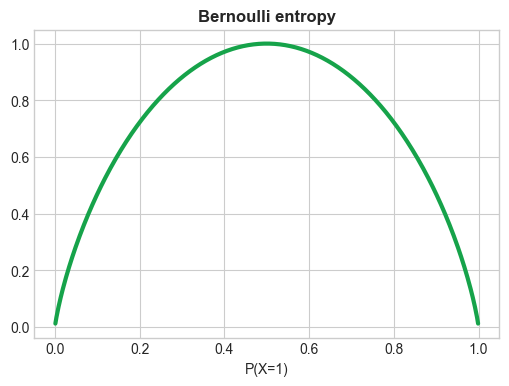

In [155]:
p = np.linspace(0.001, 0.999, 400)
H = -(p*np.log2(p) + (1-p)*np.log2(1-p))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p, H, color=COLORS["green"], linewidth=3)
ax.set_title("Bernoulli entropy", weight="bold")
ax.set_xlabel("P(X=1)")
plt.show()


**Graph explanation.** The curve peaks at 0.5 because a fair binary outcome is most uncertain. It falls near 0 or 1 because the outcome becomes predictable.


## Block 61 - Conditional probability

**Concept.** Conditional probability measures probability after information is known.

**Notation.** $P(A\mid B)=\frac{P(A\cap B)}{P(B)}$.

**Theory.** Conditioning changes the reference population.

**Math example.** If 20 of 50 students are advanced and 10 advanced students pass, then $P(pass\mid advanced)=10/20$.

**Best ML example.** Bayes classifiers and probabilistic reasoning use conditional probabilities.

**Visualization.** The denominator is the restricted group $B$.


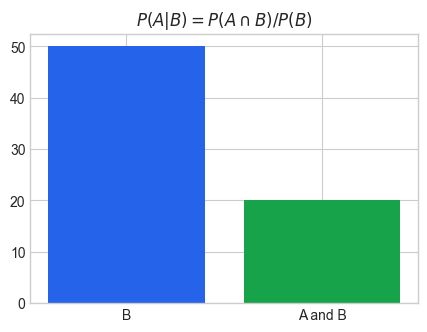

P(A|B) = 0.4


In [156]:
counts = {"B": 50, "A and B": 20}
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["B", "A and B"], [counts["B"], counts["A and B"]], color=[COLORS["blue"], COLORS["green"]])
ax.set_title(r"$P(A|B)=P(A\cap B)/P(B)$", weight="bold")
plt.show()
print("P(A|B) =", counts["A and B"] / counts["B"])


**Graph explanation.** The smaller bar is the event inside the condition group. Conditional probability divides by the size of the condition group.


## Block 62 - i.i.d. random variables

**Concept.** i.i.d. means independent and identically distributed.

**Notation.** $X_1,\ldots,X_n\overset{i.i.d.}{\sim}p$.

**Theory.** Independent means samples do not affect each other; identically distributed means each follows the same distribution.

**Math example.** Repeated fair coin flips are often modeled as i.i.d. Bernoulli(0.5).

**Best ML example.** Many training datasets are assumed to contain i.i.d. samples.

**Visualization.** Multiple samples come from the same distribution.


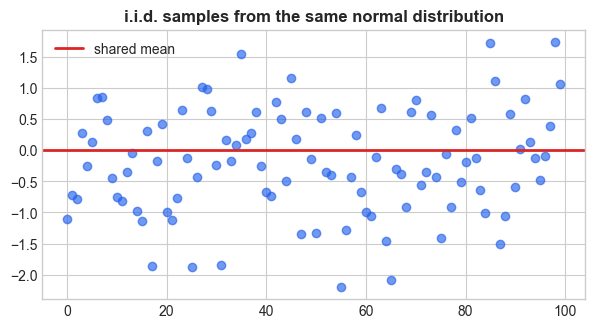

In [157]:
rng = np.random.default_rng(10)
samples = rng.normal(0, 1, 100)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(samples, marker="o", linestyle="", alpha=0.65, color=COLORS["blue"])
ax.axhline(0, color=COLORS["red"], linewidth=2, label="shared mean")
ax.set_title("i.i.d. samples from the same normal distribution", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The points fluctuate randomly around the same mean. The picture suggests samples drawn independently from one shared distribution.


## Block 63 - Jacobian: derivative of vector-valued functions

**Concept.** The Jacobian collects first derivatives for a vector-valued function.

**Notation.** $J_f(\mathbf{x})=\frac{\partial \mathbf{f}}{\partial \mathbf{x}}$.

**Theory.** If $f:\mathbb{R}^n\to\mathbb{R}^m$, then the Jacobian has shape $m\times n$.

**Math example.** For $f(x,y)=[x^2+y,\ xy]^T$, $J=\begin{bmatrix}2x&1\\y&x\end{bmatrix}$.

**Best ML example.** Jacobians describe sensitivity of model outputs to inputs and are central to backpropagation.

**Visualization.** A small square is locally transformed by the Jacobian.


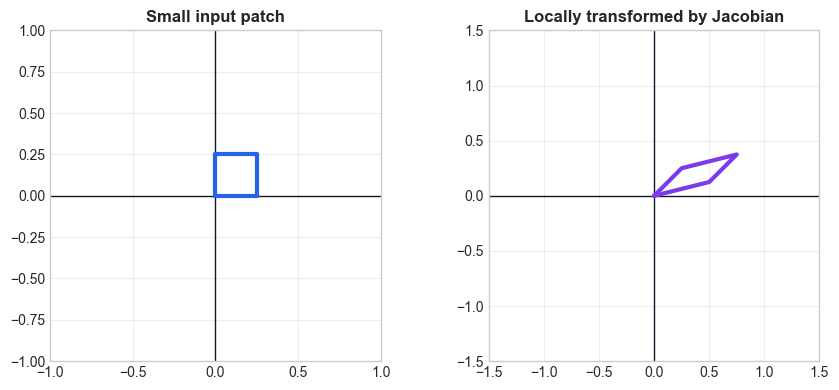

J =
 [[2.  1. ]
 [0.5 1. ]]


In [158]:
x0, y0 = 1.0, 0.5
J = np.array([[2*x0, 1], [y0, x0]])
square = np.array([[0,0], [0.25,0], [0.25,0.25], [0,0.25], [0,0]]).T
mapped = J @ square
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
setup_2d_axis(axes[0], limit=1, title="Small input patch")
axes[0].plot(square[0], square[1], color=COLORS["blue"], linewidth=3)
setup_2d_axis(axes[1], limit=1.5, title="Locally transformed by Jacobian")
axes[1].plot(mapped[0], mapped[1], color=COLORS["purple"], linewidth=3)
plt.tight_layout()
plt.show()
print("J =\n", J)


**Graph explanation.** The small input patch is transformed into a new local shape. The Jacobian is the linear map that best describes this local change.


## Block 64 - Hessian: second-derivative curvature matrix

**Concept.** The Hessian collects second derivatives of a scalar-valued function.

**Notation.** $\nabla^2 f(\mathbf{x})$ or $H_f(\mathbf{x})$.

**Theory.** The Hessian describes local curvature. Positive definite Hessian suggests a local minimum.

**Math example.** For $f(x,y)=x^2+3y^2+xy$, $H=\begin{bmatrix}2&1\\1&6\end{bmatrix}$.

**Best ML example.** Hessians explain optimization curvature, Newton's method, and why some loss landscapes are steep in one direction and flat in another.

**Visualization.** Elliptical contours reveal unequal curvature directions.


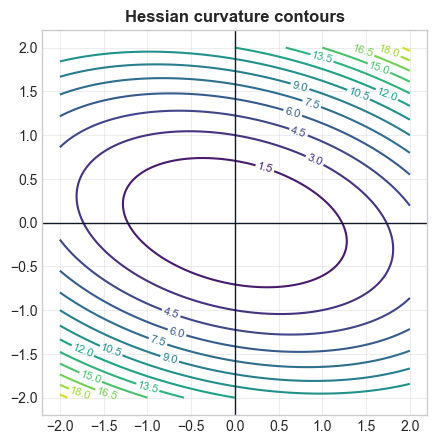

Hessian eigenvalues = [1.764 6.236]


In [159]:
H = np.array([[2, 1], [1, 6]], dtype=float)
x = np.linspace(-2, 2, 240)
y = np.linspace(-2, 2, 240)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (H[0,0]*X**2 + 2*H[0,1]*X*Y + H[1,1]*Y**2)
fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(X, Y, Z, levels=14, cmap="viridis")
ax.clabel(cs, inline=True, fontsize=8)
setup_2d_axis(ax, limit=2.2, title=r"Hessian curvature contours")
plt.show()
print("Hessian eigenvalues =", np.linalg.eigvals(H))


**Graph explanation.** The contour ellipses reveal second-order curvature. The Hessian eigenvalues describe how steep the bowl is along its principal directions.


## Block 65 - Chain rule: derivatives through composed functions

**Concept.** The chain rule tells us how a change flows through a composition of functions.

**Notation.** If $y=f(g(x))$, then $\frac{dy}{dx}=f'(g(x))g'(x)$.

**Theory.** Deep networks are compositions of many functions, so training depends on repeatedly applying the chain rule.

**Math example.** If $y=(3x+1)^2$, then $\frac{dy}{dx}=2(3x+1)\cdot3$.

**Best ML/LLM example.** Backpropagation is the chain rule applied layer by layer from loss back to parameters.

**Visualization.** A composed function and its derivative are plotted together.


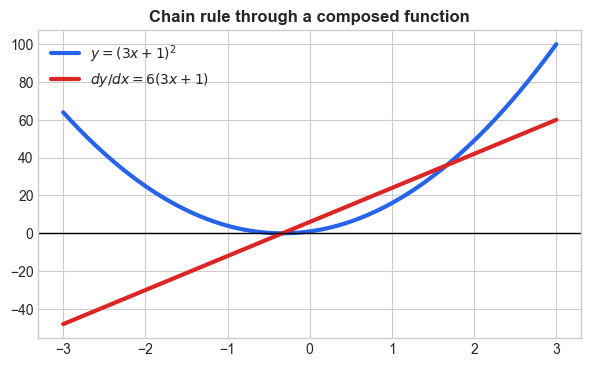

In [160]:
x = np.linspace(-3, 3, 300)
y = (3*x + 1)**2
dy = 6*(3*x + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, label=r"$y=(3x+1)^2$", color=COLORS["blue"], linewidth=3)
ax.plot(x, dy, label=r"$dy/dx=6(3x+1)$", color=COLORS["red"], linewidth=3)
ax.axhline(0, color="black", linewidth=1)
ax.legend()
ax.set_title("Chain rule through a composed function", weight="bold")
plt.show()


**Graph explanation.** The two curves show a composed function and its derivative. The derivative comes from multiplying the outer and inner rates of change.


## Block 66 - Backpropagation: gradients through a network

**Concept.** Backpropagation efficiently computes gradients of the loss with respect to every parameter.

**Notation.** $\frac{\partial \mathcal{L}}{\partial w}$ for each weight $w$.

**Theory.** Backprop stores intermediate values during the forward pass and reuses them during the backward pass.

**Math example.** For $\hat y=wx+b$ and $\mathcal{L}=(\hat y-y)^2$, $\frac{\partial \mathcal{L}}{\partial w}=2(\hat y-y)x$.

**Best ML/LLM example.** Every neural network, CNN, transformer, and LLM is trained using backpropagation.

**Visualization.** A tiny one-neuron model shows forward values and backward gradients.


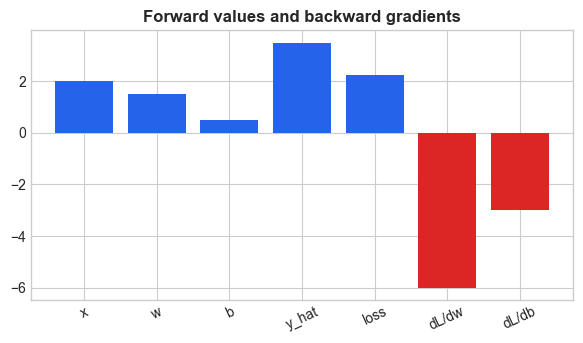

y_hat = 3.5 loss = 2.25 dL/dw = -6.0 dL/db = -3.0


In [161]:
x, y_true = 2.0, 5.0
w, b = 1.5, 0.5
y_hat = w*x + b
loss = (y_hat - y_true)**2
dL_dw = 2*(y_hat - y_true)*x
dL_db = 2*(y_hat - y_true)
fig, ax = plt.subplots(figsize=(7, 3.5))
labels = ["x", "w", "b", "y_hat", "loss", "dL/dw", "dL/db"]
values = [x, w, b, y_hat, loss, dL_dw, dL_db]
ax.bar(labels, values, color=[COLORS["blue"]]*5 + [COLORS["red"], COLORS["red"]])
ax.set_title("Forward values and backward gradients", weight="bold")
plt.xticks(rotation=25)
plt.show()
print("y_hat =", y_hat, "loss =", loss, "dL/dw =", dL_dw, "dL/db =", dL_db)


**Graph explanation.** The arrows show the direction of steepest increase. For a bowl-shaped function, gradients point outward from the minimum.


## Block 67 - Matrix calculus: gradients with respect to vectors and matrices

**Concept.** Matrix calculus extends derivatives to vector and matrix expressions.

**Notation.** $\nabla_\mathbf{w}\mathcal{L}$, $\frac{\partial \mathcal{L}}{\partial \mathbf{W}}$.

**Theory.** For $\mathcal{L}=\|\mathbf{Xw}-\mathbf{y}\|_2^2$, $\nabla_\mathbf{w}\mathcal{L}=2\mathbf{X}^T(\mathbf{Xw}-\mathbf{y})$.

**Math example.** The gradient has the same shape as $\mathbf{w}$.

**Best ML/LLM example.** Optimizers update parameter matrices using matrix-shaped gradients.

**Visualization.** The analytic gradient is checked against a finite-difference gradient.


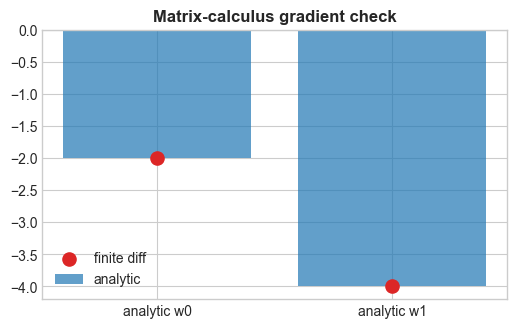

analytic: [-2. -4.] finite difference: [-2. -4.]


In [162]:
X = np.array([[1, 1], [1, 2], [1, 3]], dtype=float)
y = np.array([2, 2.5, 4.0])
w = np.array([0.5, 1.0])
grad = 2 * X.T @ (X @ w - y)
eps = 1e-5
fd = []
for j in range(len(w)):
    e = np.zeros_like(w); e[j] = eps
    lp = np.sum((X @ (w + e) - y)**2)
    lm = np.sum((X @ (w - e) - y)**2)
    fd.append((lp - lm) / (2*eps))
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["analytic w0", "analytic w1"], grad, alpha=0.7, label="analytic")
ax.scatter(["analytic w0", "analytic w1"], fd, color=COLORS["red"], s=90, label="finite diff")
ax.set_title("Matrix-calculus gradient check", weight="bold")
ax.legend()
plt.show()
print("analytic:", grad, "finite difference:", np.array(fd))


**Graph explanation.** The plot shows that vector coordinates are ordered. Swapping the same two numbers changes the endpoint and direction, which is why feature order must stay consistent in machine learning.


## Block 68 - Activation functions: ReLU, tanh, GELU, and swish

**Concept.** Activation functions add nonlinearity so neural networks can model complex patterns.

**Notation.** $\operatorname{ReLU}(x)=\max(0,x)$, $\tanh(x)$, $\operatorname{GELU}(x)$, $\operatorname{swish}(x)=x\sigma(x)$.

**Theory.** Without nonlinear activations, stacked neural layers collapse into a single linear transformation.

**Math example.** $\operatorname{ReLU}(-2)=0$ and $\operatorname{ReLU}(3)=3$.

**Best ML/LLM example.** Transformers commonly use GELU or related smooth activations in feed-forward layers.

**Visualization.** Several activation curves are compared.


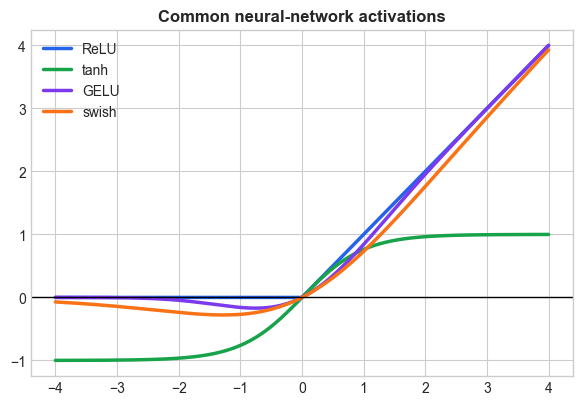

In [163]:
x = np.linspace(-4, 4, 400)
sig = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)
gelu = 0.5*x*(1 + np.tanh(np.sqrt(2/np.pi)*(x + 0.044715*x**3)))
swish = x * sig
fig, ax = plt.subplots(figsize=(7, 4.5))
for y, name, color in [(relu, "ReLU", COLORS["blue"]), (tanh, "tanh", COLORS["green"]), (gelu, "GELU", COLORS["purple"]), (swish, "swish", COLORS["orange"])]:
    ax.plot(x, y, label=name, linewidth=2.5, color=color)
ax.axhline(0, color="black", linewidth=1)
ax.legend()
ax.set_title("Common neural-network activations", weight="bold")
plt.show()


**Graph explanation.** Each curve shows a different nonlinear transformation. These nonlinearities are what let neural networks model more than one big linear map.


## Block 69 - Vanishing and exploding gradients

**Concept.** Gradients can shrink toward zero or grow uncontrollably as they pass through many layers.

**Notation.** Products like $\prod_{\ell=1}^L W_\ell$ appear in deep gradient flow.

**Theory.** Repeated multiplication by factors below 1 causes vanishing; above 1 causes exploding.

**Math example.** $0.8^{50}\approx0.000014$ while $1.2^{50}\approx9100$.

**Best ML/LLM example.** Residual connections, normalization, and careful initialization help train deep transformers.

**Visualization.** Repeated multiplication is shown on a log scale.


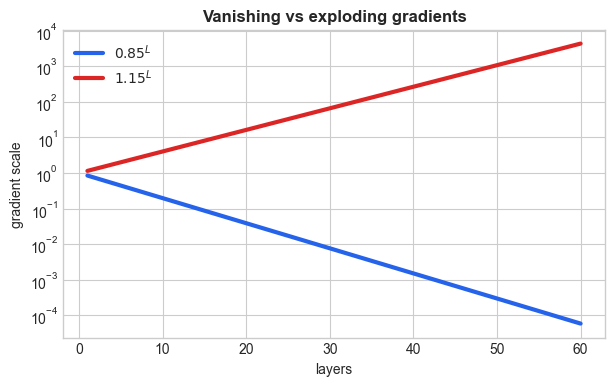

In [164]:
layers = np.arange(1, 61)
vanish = 0.85**layers
explode = 1.15**layers
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(layers, vanish, label=r"$0.85^L$", color=COLORS["blue"], linewidth=3)
ax.semilogy(layers, explode, label=r"$1.15^L$", color=COLORS["red"], linewidth=3)
ax.set_xlabel("layers")
ax.set_ylabel("gradient scale")
ax.set_title("Vanishing vs exploding gradients", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The arrows show the direction of steepest increase. For a bowl-shaped function, gradients point outward from the minimum.


## Block 70 - Gradient descent

**Concept.** Gradient descent updates parameters in the direction that reduces loss.

**Notation.** $\theta_{t+1}=\theta_t-\eta\nabla_\theta\mathcal{L}(\theta_t)$.

**Theory.** The learning rate $\eta$ controls the step size.

**Math example.** For $\mathcal{L}(\theta)=(\theta-3)^2$, the gradient is $2(\theta-3)$.

**Best ML/LLM example.** Most neural optimizers are descendants of gradient descent.

**Visualization.** Updates move toward the minimum.


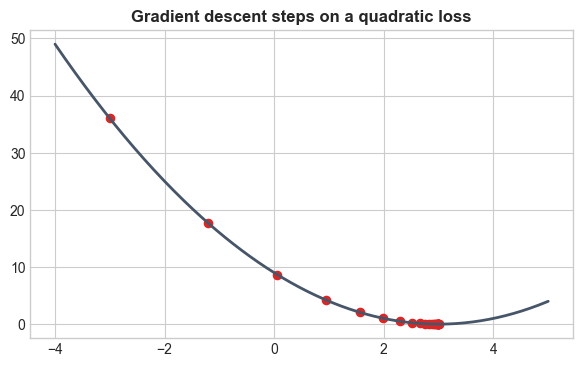

In [165]:
theta = -3.0
eta = 0.15
history = []
for _ in range(25):
    history.append(theta)
    theta -= eta * 2*(theta - 3)
grid = np.linspace(-4, 5, 300)
loss = (grid - 3)**2
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, loss, color=COLORS["gray"], linewidth=2)
ax.scatter(history, [(t-3)**2 for t in history], color=COLORS["red"], s=35)
ax.set_title("Gradient descent steps on a quadratic loss", weight="bold")
plt.show()


**Graph explanation.** The arrows show the direction of steepest increase. For a bowl-shaped function, gradients point outward from the minimum.


## Block 71 - SGD, mini-batches, and noisy gradients

**Concept.** Stochastic gradient descent estimates gradients from one sample or a mini-batch.

**Notation.** $\nabla\mathcal{L}_{\mathcal{B}}(\theta)$ for batch $\mathcal{B}$.

**Theory.** Mini-batch gradients are noisy but efficient and often help generalization.

**Math example.** A batch of 32 examples estimates the full-dataset gradient.

**Best ML/LLM example.** LLM training uses mini-batches of token sequences.

**Visualization.** Noisy SGD steps wiggle around the smooth descent path.


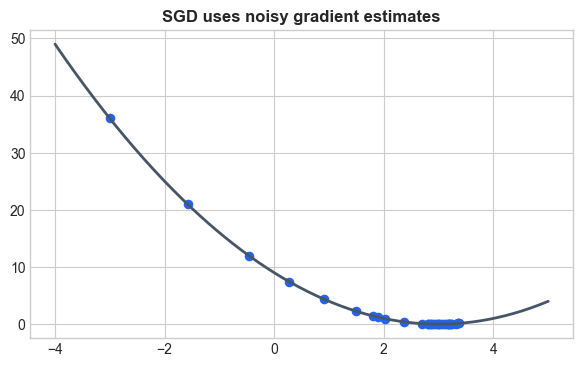

In [166]:
rng = np.random.default_rng(0)
theta = -3.0
eta = 0.12
hist = []
for _ in range(35):
    noisy_grad = 2*(theta - 3) + rng.normal(0, 1.2)
    hist.append(theta)
    theta -= eta * noisy_grad
fig, ax = plt.subplots(figsize=(7, 4))
grid = np.linspace(-4, 5, 300)
ax.plot(grid, (grid-3)**2, color=COLORS["gray"], linewidth=2)
ax.scatter(hist, [(t-3)**2 for t in hist], color=COLORS["blue"], s=35)
ax.set_title("SGD uses noisy gradient estimates", weight="bold")
plt.show()


**Graph explanation.** The arrows show the direction of steepest increase. For a bowl-shaped function, gradients point outward from the minimum.


## Block 72 - Momentum, RMSProp, and Adam

**Concept.** Adaptive optimizers use memory of past gradients to improve training.

**Notation.** Momentum uses $v_t=\beta v_{t-1}+(1-\beta)g_t$; Adam tracks first and second moments.

**Theory.** Momentum smooths direction; RMSProp and Adam scale updates by recent gradient magnitudes.

**Math example.** Large recent gradients reduce the effective step size in Adam/RMSProp.

**Best ML/LLM example.** AdamW is a standard optimizer for transformers and LLMs.

**Visualization.** Different optimizers make different update paths on the same 1D loss.


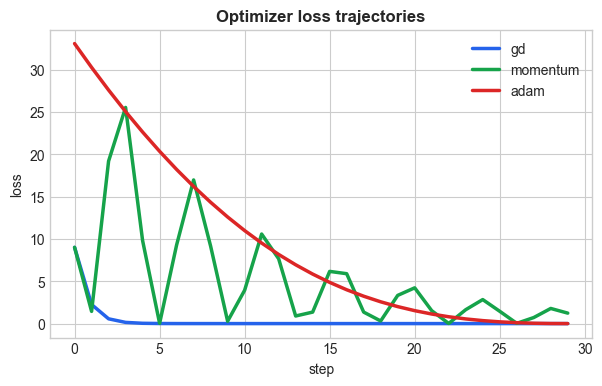

In [167]:
def run(method, steps=30):
    theta, lr = -4.0, 0.25
    v, s = 0.0, 0.0
    hist = []
    for t in range(1, steps+1):
        g = 2*(theta - 2)
        if method == "gd":
            update = g
        elif method == "momentum":
            v = 0.9*v + g
            update = v
        else:
            v = 0.9*v + 0.1*g
            s = 0.999*s + 0.001*g*g
            update = (v/(1-0.9**t)) / (np.sqrt(s/(1-0.999**t)) + 1e-8)
        theta -= lr * update
        hist.append(theta)
    return np.array(hist)
fig, ax = plt.subplots(figsize=(7, 4))
for method, color in [("gd", COLORS["blue"]), ("momentum", COLORS["green"]), ("adam", COLORS["red"])]:
    h = run(method)
    ax.plot((h-2)**2, label=method, color=color, linewidth=2.5)
ax.set_title("Optimizer loss trajectories", weight="bold")
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.legend()
plt.show()


**Graph explanation.** The trajectories show how optimizer choices affect convergence. Momentum and Adam use gradient history instead of only the current gradient.


## Block 73 - Weight initialization: Xavier and He

**Concept.** Initialization chooses starting weights so signals and gradients do not immediately vanish or explode.

**Notation.** Xavier: $\operatorname{Var}(W)\approx 1/n_{in}$; He: $\operatorname{Var}(W)\approx 2/n_{in}$.

**Theory.** The right scale depends on layer width and activation function.

**Math example.** For $n_{in}=100$, He standard deviation is $\sqrt{2/100}$.

**Best ML/LLM example.** Large transformers require carefully scaled initialization for stable training.

**Visualization.** Xavier and He initializations create different weight spreads.


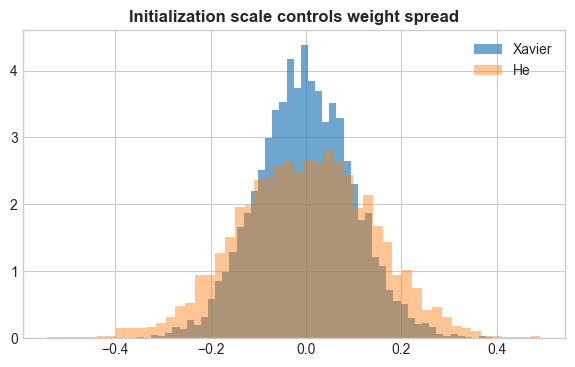

In [168]:
rng = np.random.default_rng(1)
n_in = 100
xavier = rng.normal(0, np.sqrt(1/n_in), 5000)
he = rng.normal(0, np.sqrt(2/n_in), 5000)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(xavier, bins=50, alpha=0.65, label="Xavier", density=True)
ax.hist(he, bins=50, alpha=0.45, label="He", density=True)
ax.set_title("Initialization scale controls weight spread", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The histograms show different starting weight spreads. He initialization is wider here because it is designed for ReLU-like activations.


## Block 74 - Normalization: batch norm and layer norm

**Concept.** Normalization rescales activations to stabilize training.

**Notation.** $\hat x=(x-\mu)/\sqrt{\sigma^2+\epsilon}$.

**Theory.** BatchNorm normalizes using batch statistics; LayerNorm normalizes within each sample.

**Math example.** A row can be normalized to mean 0 and variance 1.

**Best ML/LLM example.** Transformers use LayerNorm/RMSNorm to stabilize deep residual stacks.

**Visualization.** Raw activations become centered and scaled.


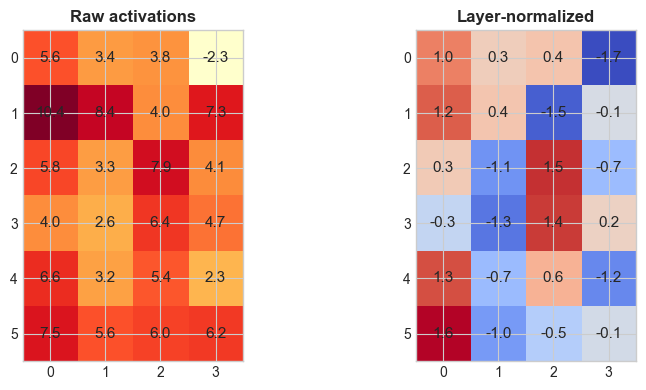

row means after layer norm: [ 0.  0. -0. -0.  0. -0.]


In [169]:
rng = np.random.default_rng(2)
X = rng.normal(5, 3, size=(6, 4))
layer_norm = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show_matrix(axes[0], X, "Raw activations", cmap="YlOrRd")
show_matrix(axes[1], layer_norm, "Layer-normalized", cmap="coolwarm")
plt.tight_layout()
plt.show()
print("row means after layer norm:", layer_norm.mean(axis=1))


**Graph explanation.** The before-and-after heatmaps show activations being centered and scaled. LayerNorm normalizes each row/sample separately.


## Block 75 - Regularization: L1, L2, dropout, and weight decay

**Concept.** Regularization discourages overfitting by constraining model complexity.

**Notation.** L1: $\lambda\|\theta\|_1$, L2: $\lambda\|\theta\|_2^2$.

**Theory.** L1 encourages sparsity; L2/weight decay shrinks weights; dropout randomly masks activations.

**Math example.** If $\theta=[3,4]$, then $\|\theta\|_1=7$ and $\|\theta\|_2=5$.

**Best ML/LLM example.** Weight decay is widely used in transformer training.

**Visualization.** Dropout randomly removes activations.


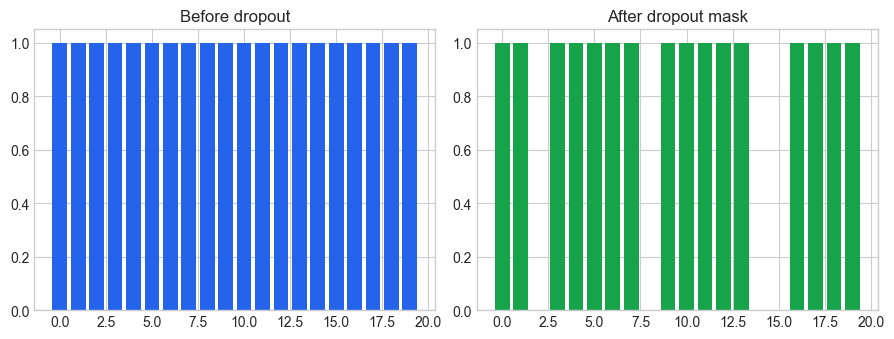

L1 = 7.0 L2 = 5.0


In [170]:
rng = np.random.default_rng(3)
activations = np.ones(20)
mask = rng.binomial(1, 0.7, size=20)
after = activations * mask
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].bar(range(20), activations, color=COLORS["blue"])
axes[0].set_title("Before dropout")
axes[1].bar(range(20), after, color=[COLORS["green"] if m else COLORS["red"] for m in mask])
axes[1].set_title("After dropout mask")
plt.tight_layout()
plt.show()
theta = np.array([3, 4])
print("L1 =", np.linalg.norm(theta, 1), "L2 =", np.linalg.norm(theta, 2))


**Graph explanation.** The dropout chart shows activations randomly kept or removed. This prevents the model from depending too strongly on exact activation patterns.


## Block 76 - Learning-rate schedules

**Concept.** A learning-rate schedule changes the step size during training.

**Notation.** $\eta_t$ is the learning rate at training step $t$.

**Theory.** Warmup prevents unstable early steps; decay helps convergence later.

**Math example.** Cosine decay gradually lowers $\eta$ from a maximum toward zero.

**Best ML/LLM example.** Transformer training commonly uses warmup followed by cosine or inverse-square-root decay.

**Visualization.** Warmup plus cosine decay is plotted.


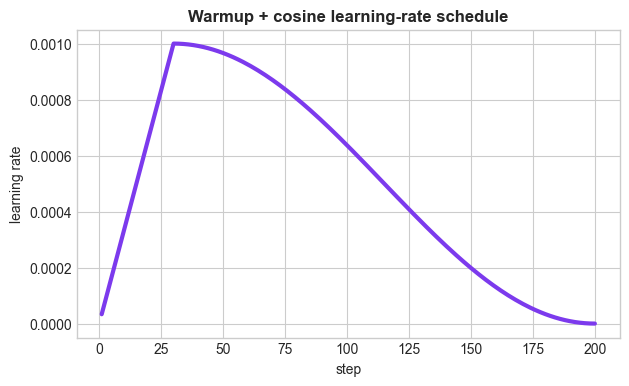

In [171]:
steps = np.arange(1, 201)
warmup = 30
base = 1e-3
lr = np.where(steps <= warmup, base*steps/warmup, base*0.5*(1 + np.cos(np.pi*(steps-warmup)/(steps[-1]-warmup))))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps, lr, color=COLORS["purple"], linewidth=3)
ax.set_title("Warmup + cosine learning-rate schedule", weight="bold")
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
plt.show()


**Graph explanation.** The curve starts with warmup and then decays. Warmup stabilizes early training; decay makes later updates more precise.


## Block 77 - Tensors and tensor shapes

**Concept.** A tensor is a multidimensional array. Scalars, vectors, and matrices are 0D, 1D, and 2D tensors.

**Notation.** A batch of token embeddings may have shape $(B,T,d)$.

**Theory.** Shape literacy prevents most deep-learning implementation errors.

**Math example.** $B=2$, $T=4$, $d=3$ gives a tensor with shape $(2,4,3)$.

**Best ML/LLM example.** LLM activations are usually batch by sequence length by hidden dimension.

**Visualization.** A 3D tensor is shown as stacked matrices.


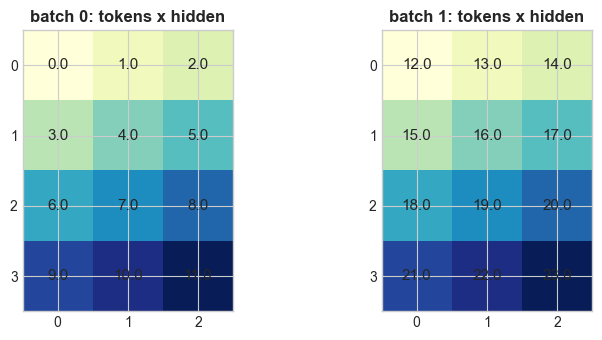

tensor shape = (2, 4, 3)


In [172]:
X = np.arange(2*4*3).reshape(2, 4, 3)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for b in range(2):
    show_matrix(axes[b], X[b], f"batch {b}: tokens x hidden", cmap="YlGnBu")
plt.tight_layout()
plt.show()
print("tensor shape =", X.shape)


**Graph explanation.** Each heatmap is one slice of a 3D tensor. This mirrors how batches contain multiple token-by-hidden matrices.


## Block 78 - Deep-learning broadcasting

**Concept.** Broadcasting applies smaller tensors across larger tensors when shapes are compatible.

**Notation.** $(B,T,d)+(d)\rightarrow(B,T,d)$.

**Theory.** Bias vectors, position embeddings, and normalization parameters rely on broadcasting.

**Math example.** Adding a hidden-size bias vector to every token in every batch.

**Best ML/LLM example.** Transformer layers add position embeddings and bias terms through broadcasting.

**Visualization.** One bias vector is added across all rows.


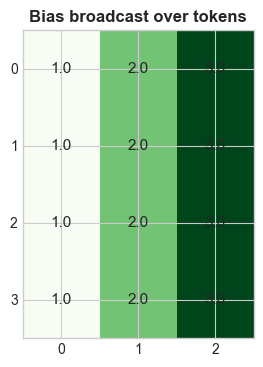

X shape: (2, 4, 3) bias shape: (3,) Y shape: (2, 4, 3)


In [173]:
X = np.zeros((2, 4, 3))
bias = np.array([1.0, 2.0, 3.0])
Y = X + bias
fig, ax = plt.subplots(figsize=(5, 4))
show_matrix(ax, Y[0], "Bias broadcast over tokens", cmap="Greens")
plt.show()
print("X shape:", X.shape, "bias shape:", bias.shape, "Y shape:", Y.shape)


**Graph explanation.** The second heatmap shows each feature column after subtracting its mean. Broadcasting applies the same mean vector to every row.


## Block 79 - Embeddings

**Concept.** An embedding maps a discrete item to a learned dense vector.

**Notation.** $\mathbf{e}_i=\mathbf{E}[i]$ where $\mathbf{E}\in\mathbb{R}^{V\times d}$.

**Theory.** Nearby embedding vectors often represent related meanings or roles.

**Math example.** Token id 3 selects row 3 of the embedding matrix.

**Best ML/LLM example.** LLMs begin by converting token ids into embedding vectors.

**Visualization.** Token ids index rows in an embedding table.


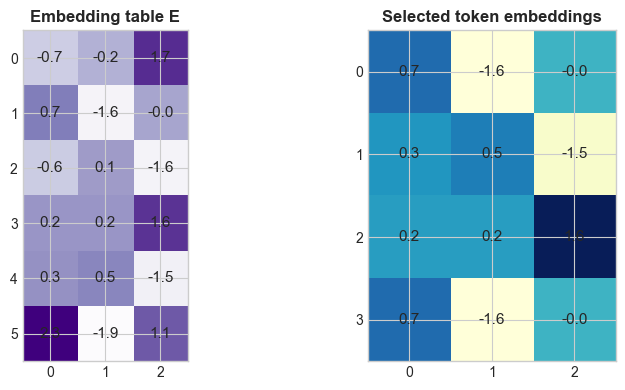

token_ids: [1 4 3 1] selected shape: (4, 3)


In [174]:
rng = np.random.default_rng(4)
E = rng.normal(size=(6, 3))
token_ids = np.array([1, 4, 3, 1])
emb = E[token_ids]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show_matrix(axes[0], E, "Embedding table E", cmap="Purples")
show_matrix(axes[1], emb, "Selected token embeddings", cmap="YlGnBu")
plt.tight_layout()
plt.show()
print("token_ids:", token_ids, "selected shape:", emb.shape)


**Graph explanation.** The left heatmap is the lookup table and the right heatmap shows selected rows. Token ids choose vectors from the embedding matrix.


## Block 80 - Cosine similarity in embedding space

**Concept.** Cosine similarity measures angle-based similarity between embeddings.

**Notation.** $\cos(\mathbf{a},\mathbf{b})=\frac{\mathbf{a}^T\mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}$.

**Theory.** Cosine ignores vector magnitude and focuses on direction.

**Math example.** Identical directions have cosine similarity 1.

**Best ML/LLM example.** Semantic search compares query and document embeddings with cosine similarity.

**Visualization.** A similarity matrix compares several embeddings.


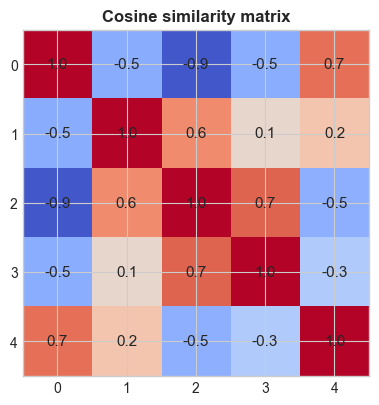

In [175]:
rng = np.random.default_rng(5)
E = rng.normal(size=(5, 4))
E = E / np.linalg.norm(E, axis=1, keepdims=True)
S = E @ E.T
fig, ax = plt.subplots(figsize=(5, 4.5))
show_matrix(ax, S, "Cosine similarity matrix", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()


**Graph explanation.** The matrix compares every embedding with every other embedding. Diagonal values are highest because each vector matches itself.


## Block 81 - Attention: weighted information retrieval

**Concept.** Attention lets each token gather information from other tokens using learned weights.

**Notation.** $\operatorname{Attention}(Q,K,V)=\operatorname{softmax}(QK^T/\sqrt{d_k})V$.

**Theory.** Queries ask questions, keys are matched against queries, and values provide information.

**Math example.** A token attends strongly to another token when their query-key dot product is large.

**Best ML/LLM example.** Self-attention is the central operation in transformer LLMs.

**Visualization.** Attention weights show which tokens look at which other tokens.


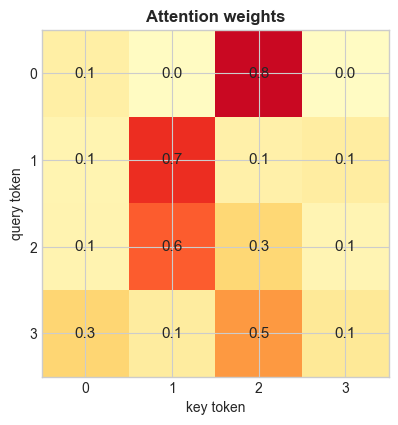

In [176]:
rng = np.random.default_rng(6)
Q = rng.normal(size=(4, 3))
K = rng.normal(size=(4, 3))
scores = Q @ K.T / np.sqrt(3)
weights = np.exp(scores - scores.max(axis=1, keepdims=True))
weights = weights / weights.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(5, 4.5))
show_matrix(ax, weights, "Attention weights", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xlabel("key token")
ax.set_ylabel("query token")
plt.show()


**Graph explanation.** Each row is a query token and each column is a key token. Brighter cells show where a token pays more attention.


## Block 82 - Q, K, and V projection matrices

**Concept.** Query, Key, and Value vectors are produced by learned linear projections.

**Notation.** $Q=XW_Q$, $K=XW_K$, $V=XW_V$.

**Theory.** The same token representation is projected into three roles: asking, matching, and carrying content.

**Math example.** If $X$ is $(T,d)$ and $W_Q$ is $(d,d_k)$, then $Q$ is $(T,d_k)$.

**Best ML/LLM example.** Every transformer attention layer learns $W_Q,W_K,W_V$.

**Visualization.** Input token vectors are projected into Q/K/V matrices.


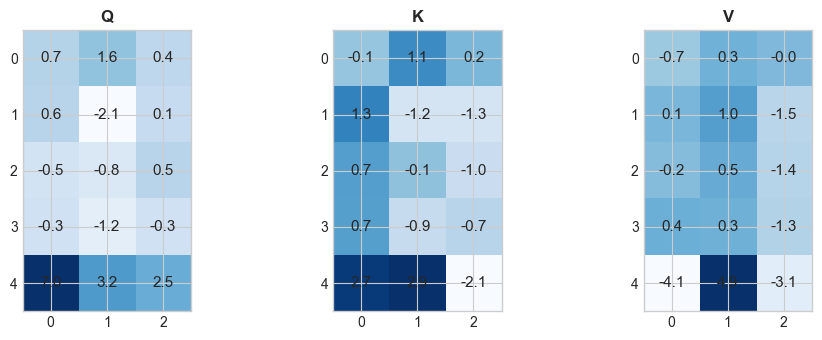

X (5, 4) Q (5, 3) K (5, 3) V (5, 3)


In [177]:
rng = np.random.default_rng(7)
X = rng.normal(size=(5, 4))
Wq, Wk, Wv = [rng.normal(size=(4, 3)) for _ in range(3)]
Q, K, V = X @ Wq, X @ Wk, X @ Wv
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, M, title in zip(axes, [Q, K, V], ["Q", "K", "V"]):
    show_matrix(ax, M, title, cmap="Blues")
plt.tight_layout()
plt.show()
print("X", X.shape, "Q", Q.shape, "K", K.shape, "V", V.shape)


**Graph explanation.** The heatmap treats each matrix entry as a colored cell. Rows represent samples, columns represent features, and the color intensity helps you quickly see which values are large or small.


## Block 83 - Scaled dot-product attention

**Concept.** Scaled dot-product attention divides scores by $\sqrt{d_k}$ before softmax.

**Notation.** $QK^T/\sqrt{d_k}$.

**Theory.** Scaling prevents large dot products from making softmax too sharp when $d_k$ is large.

**Math example.** If $d_k=64$, scores are divided by 8.

**Best ML/LLM example.** This is the attention formula used in transformers.

**Visualization.** Scaling makes attention less saturated.


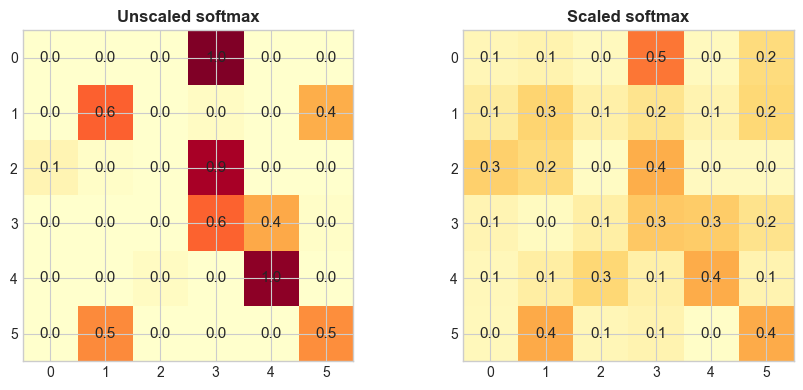

In [178]:
rng = np.random.default_rng(8)
Q = rng.normal(size=(6, 64))
K = rng.normal(size=(6, 64))
raw = Q @ K.T
scaled = raw / np.sqrt(64)
def softmax_rows(A):
    E = np.exp(A - A.max(axis=1, keepdims=True))
    return E / E.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show_matrix(axes[0], softmax_rows(raw), "Unscaled softmax", cmap="YlOrRd", vmin=0, vmax=1)
show_matrix(axes[1], softmax_rows(scaled), "Scaled softmax", cmap="YlOrRd", vmin=0, vmax=1)
plt.tight_layout()
plt.show()


**Graph explanation.** Each row is a query token and each column is a key token. Brighter cells show where a token pays more attention.


## Block 84 - Multi-head attention

**Concept.** Multi-head attention runs several attention operations in parallel.

**Notation.** $\operatorname{MHA}(X)=\operatorname{Concat}(\text{head}_1,\ldots,\text{head}_h)W_O$.

**Theory.** Different heads can focus on different relationships.

**Math example.** With hidden size 12 and 3 heads, each head may use dimension 4.

**Best ML/LLM example.** Transformer layers use many attention heads.

**Visualization.** Multiple attention heads produce different attention maps.


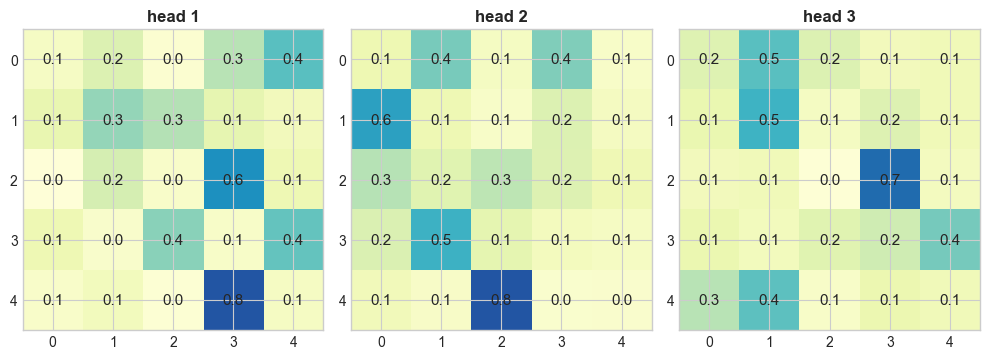

In [179]:
rng = np.random.default_rng(9)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for h, ax in enumerate(axes):
    scores = rng.normal(size=(5, 5))
    W = np.exp(scores - scores.max(axis=1, keepdims=True))
    W = W / W.sum(axis=1, keepdims=True)
    show_matrix(ax, W, f"head {h+1}", cmap="YlGnBu", vmin=0, vmax=1)
plt.tight_layout()
plt.show()


**Graph explanation.** Each row is a query token and each column is a key token. Brighter cells show where a token pays more attention.


## Block 85 - Positional encodings and rotary position ideas

**Concept.** Positional information tells a transformer where each token is in the sequence.

**Notation.** Sinusoidal encodings use $\sin(pos/\omega)$ and $\cos(pos/\omega)$; rotary methods rotate features by position.

**Theory.** Self-attention alone is permutation-invariant without positional information.

**Math example.** Position 0 and position 5 receive different vectors even if the token is the same.

**Best ML/LLM example.** LLMs use positional embeddings or RoPE-style rotary position encodings.

**Visualization.** Sinusoidal position features across sequence positions.


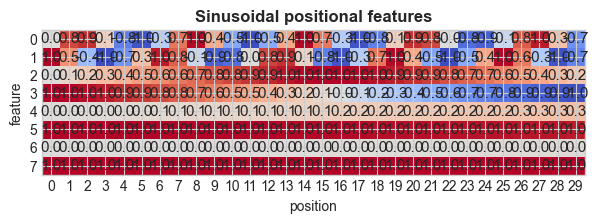

In [180]:
positions = np.arange(30)
d = 8
PE = np.zeros((len(positions), d))
for i in range(0, d, 2):
    div = 10000 ** (i / d)
    PE[:, i] = np.sin(positions / div)
    PE[:, i+1] = np.cos(positions / div)
fig, ax = plt.subplots(figsize=(7, 4))
show_matrix(ax, PE.T, "Sinusoidal positional features", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xlabel("position")
ax.set_ylabel("feature")
plt.show()


**Graph explanation.** The heatmap shows position-dependent wave patterns. These features let the model distinguish token order.


## Block 86 - Masking and causal attention

**Concept.** A causal mask prevents a token from attending to future tokens.

**Notation.** Add $-\infty$ to forbidden attention scores before softmax.

**Theory.** Causal masking makes autoregressive language modeling possible.

**Math example.** Token 3 may attend to tokens 1, 2, and 3, but not token 4.

**Best ML/LLM example.** GPT-style models use causal masks during training and generation.

**Visualization.** The lower-triangular mask shows allowed attention positions.


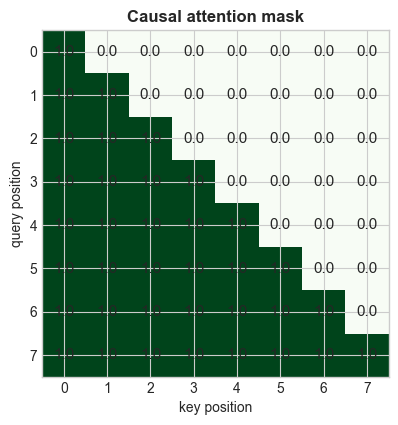

In [181]:
T = 8
mask = np.tril(np.ones((T, T)))
fig, ax = plt.subplots(figsize=(5, 4.5))
show_matrix(ax, mask, "Causal attention mask", cmap="Greens", vmin=0, vmax=1)
ax.set_xlabel("key position")
ax.set_ylabel("query position")
plt.show()


**Graph explanation.** Each row is a query token and each column is a key token. Brighter cells show where a token pays more attention.


## Block 87 - Transformer block math

**Concept.** A transformer block combines attention, residual connections, normalization, and a feed-forward network.

**Notation.** $X'=X+\operatorname{Attention}(\operatorname{LN}(X))$, then $Y=X'+\operatorname{MLP}(\operatorname{LN}(X'))$.

**Theory.** Residual paths help gradients flow through very deep networks.

**Math example.** Input and output usually keep the same hidden dimension.

**Best ML/LLM example.** LLMs stack many transformer blocks.

**Visualization.** A toy residual block preserves shape.


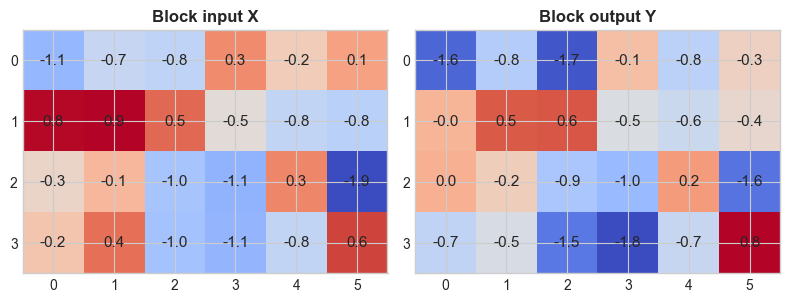

input shape: (4, 6) output shape: (4, 6)


In [182]:
rng = np.random.default_rng(10)
X = rng.normal(size=(4, 6))
def ln(A):
    return (A - A.mean(axis=-1, keepdims=True)) / (A.std(axis=-1, keepdims=True) + 1e-6)
attention_like = ln(X) @ rng.normal(size=(6, 6)) * 0.1
X_prime = X + attention_like
mlp_like = np.maximum(0, ln(X_prime) @ rng.normal(size=(6, 12))) @ rng.normal(size=(12, 6)) * 0.05
Y = X_prime + mlp_like
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
show_matrix(axes[0], X, "Block input X", cmap="coolwarm")
show_matrix(axes[1], Y, "Block output Y", cmap="coolwarm")
plt.tight_layout()
plt.show()
print("input shape:", X.shape, "output shape:", Y.shape)


**Graph explanation.** Input and output heatmaps have the same shape because transformer blocks transform representations while preserving sequence structure.


## Block 88 - Logits and temperature

**Concept.** Logits are raw scores before softmax. Temperature controls how sharp the probabilities become.

**Notation.** $p_i=\operatorname{softmax}(z_i/T)$.

**Theory.** Lower temperature sharpens; higher temperature flattens.

**Math example.** $T=0.5$ makes the largest logit more dominant than $T=2$.

**Best ML/LLM example.** Generation temperature controls creativity and randomness.

**Visualization.** The same logits are transformed with different temperatures.


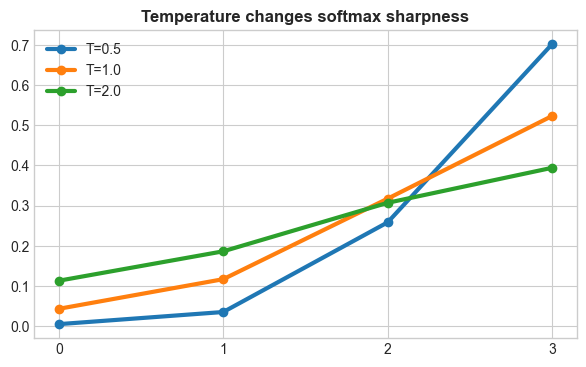

In [183]:
logits = np.array([1.0, 2.0, 3.0, 3.5])
temps = [0.5, 1.0, 2.0]
fig, ax = plt.subplots(figsize=(7, 4))
idx = np.arange(len(logits))
for T in temps:
    e = np.exp(logits/T - np.max(logits/T))
    p = e / e.sum()
    ax.plot(idx, p, marker="o", linewidth=3, label=f"T={T}")
ax.set_title("Temperature changes softmax sharpness", weight="bold")
ax.set_xticks(idx)
ax.legend()
plt.show()


**Graph explanation.** The curves show that lower temperature concentrates probability on high-scoring tokens, while higher temperature spreads probability more evenly.


## Block 89 - Perplexity

**Concept.** Perplexity measures how uncertain a language model is on average.

**Notation.** $\operatorname{PPL}=\exp(\text{cross-entropy})$.

**Theory.** Lower perplexity means the model assigns higher probability to the observed tokens.

**Math example.** Cross-entropy 2.0 gives perplexity $e^2\approx7.39$.

**Best ML/LLM example.** Perplexity is a common language-model evaluation metric.

**Visualization.** Perplexity grows exponentially with cross-entropy.


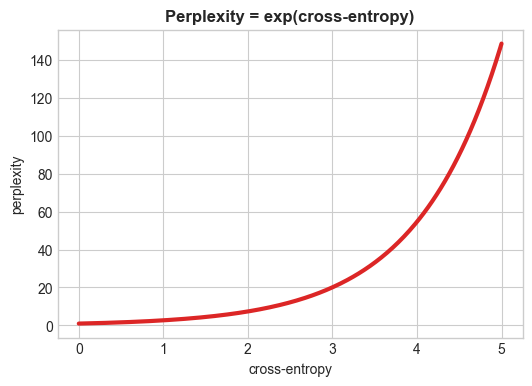

In [184]:
ce = np.linspace(0, 5, 300)
ppl = np.exp(ce)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ce, ppl, color=COLORS["red"], linewidth=3)
ax.set_title(r"Perplexity = exp(cross-entropy)", weight="bold")
ax.set_xlabel("cross-entropy")
ax.set_ylabel("perplexity")
plt.show()


**Graph explanation.** The curve shows the exponential relation between cross-entropy and perplexity. Small cross-entropy improvements can noticeably lower perplexity.


## Block 90 - Sampling: greedy, top-k, top-p, and temperature

**Concept.** Sampling rules choose the next token from a probability distribution.

**Notation.** Greedy uses $\arg\max_i p_i$; top-k keeps k tokens; top-p keeps the smallest set with cumulative probability at least p.

**Theory.** Sampling trades determinism for diversity.

**Math example.** If probabilities are $[0.5,0.2,0.15,0.1,0.05]$, top-2 keeps the first two.

**Best ML/LLM example.** LLM text generation uses temperature, top-k, and top-p controls.

**Visualization.** Different sampling filters keep different candidate tokens.


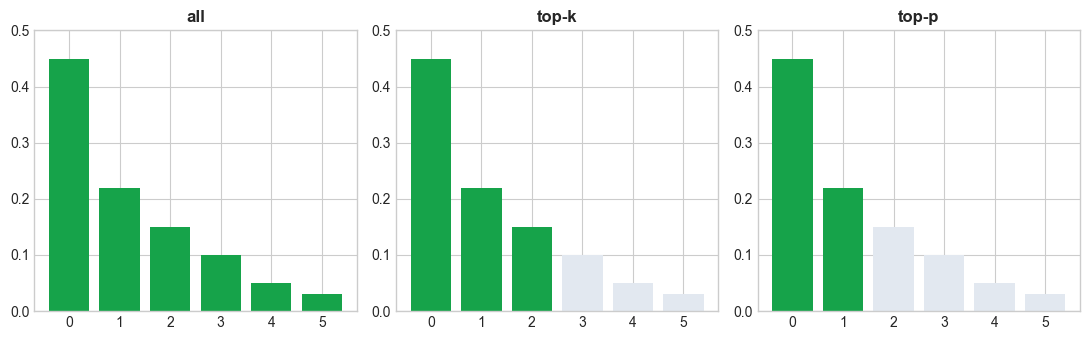

In [185]:
probs = np.array([0.45, 0.22, 0.15, 0.10, 0.05, 0.03])
top_k = 3
top_p = 0.8
order = np.argsort(probs)[::-1]
keep_k = np.zeros_like(probs, dtype=bool); keep_k[order[:top_k]] = True
cumsum = np.cumsum(probs[order])
keep_p = np.zeros_like(probs, dtype=bool); keep_p[order[cumsum <= top_p]] = True; keep_p[order[0]] = True
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, keep, title in [(axes[0], np.ones_like(probs, dtype=bool), "all"), (axes[1], keep_k, "top-k"), (axes[2], keep_p, "top-p")]:
    ax.bar(range(len(probs)), probs, color=[COLORS["green"] if k else COLORS["light"] for k in keep])
    ax.set_ylim(0, 0.5)
    ax.set_title(title, weight="bold")
plt.tight_layout()
plt.show()


**Graph explanation.** The charts show which token candidates remain after each sampling rule. Greedier filters keep fewer options.


## Block 91 - Bayes theorem

**Concept.** Bayes theorem updates beliefs after observing evidence.

**Notation.** $P(A\mid B)=\frac{P(B\mid A)P(A)}{P(B)}$.

**Theory.** Posterior is proportional to likelihood times prior.

**Math example.** A positive test result changes disease probability according to test accuracy and base rate.

**Best ML/LLM example.** Bayesian ML combines prior assumptions with data likelihood.

**Visualization.** Prior, likelihood, and posterior are compared.


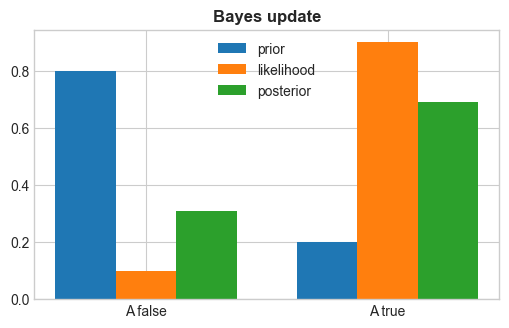

In [186]:
prior = np.array([0.8, 0.2])
likelihood = np.array([0.1, 0.9])
unnorm = prior * likelihood
posterior = unnorm / unnorm.sum()
fig, ax = plt.subplots(figsize=(6, 3.5))
w = 0.25; idx = np.arange(2)
ax.bar(idx-w, prior, width=w, label="prior")
ax.bar(idx, likelihood, width=w, label="likelihood")
ax.bar(idx+w, posterior, width=w, label="posterior")
ax.set_xticks(idx, ["A false", "A true"])
ax.set_title("Bayes update", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The bars show belief before evidence, evidence strength, and the updated posterior. Bayes theorem combines the first two into the third.


## Block 92 - Maximum likelihood estimation

**Concept.** MLE chooses parameters that make the observed data most probable.

**Notation.** $\hat\theta_{MLE}=\arg\max_\theta p(D\mid\theta)$.

**Theory.** Equivalently, maximize log-likelihood or minimize negative log-likelihood.

**Math example.** For Bernoulli data, the MLE of probability is the sample mean.

**Best ML/LLM example.** Language models are trained to maximize likelihood of next tokens.

**Visualization.** Bernoulli likelihood peaks at the observed success rate.


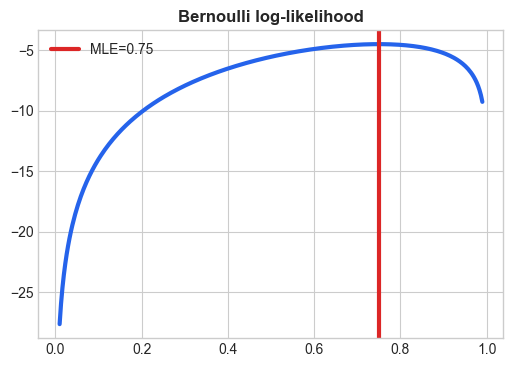

In [187]:
data = np.array([1, 0, 1, 1, 0, 1, 1, 1])
theta = np.linspace(0.01, 0.99, 300)
ll = data.sum()*np.log(theta) + (len(data)-data.sum())*np.log(1-theta)
mle = data.mean()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(theta, ll, color=COLORS["blue"], linewidth=3)
ax.axvline(mle, color=COLORS["red"], linewidth=3, label=f"MLE={mle:.2f}")
ax.set_title("Bernoulli log-likelihood", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The peak of the curve is the parameter that makes the observed data most likely.


## Block 93 - MAP estimation

**Concept.** MAP estimation chooses the most likely parameter after combining prior and data.

**Notation.** $\hat\theta_{MAP}=\arg\max_\theta p(\theta\mid D)$.

**Theory.** MAP maximizes likelihood times prior, or log-likelihood plus log-prior.

**Math example.** A Beta prior plus Bernoulli data produces a Beta posterior.

**Best ML/LLM example.** Regularization can be interpreted as MAP estimation with a prior over parameters.

**Visualization.** Prior pulls the estimate away from pure MLE.


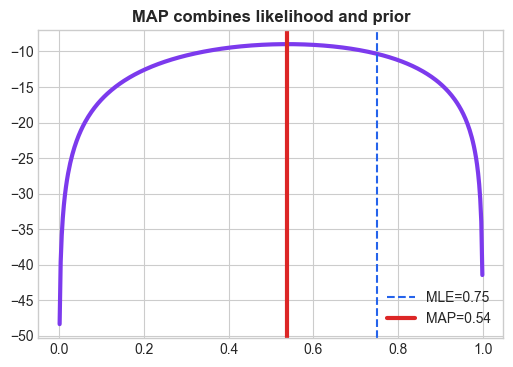

In [188]:
success, fail = 6, 2
a, b = 2, 5
theta = np.linspace(0.001, 0.999, 400)
log_post = (success+a-1)*np.log(theta) + (fail+b-1)*np.log(1-theta)
map_est = theta[np.argmax(log_post)]
mle = success / (success + fail)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(theta, log_post, color=COLORS["purple"], linewidth=3)
ax.axvline(mle, color=COLORS["blue"], linestyle="--", label=f"MLE={mle:.2f}")
ax.axvline(map_est, color=COLORS["red"], linewidth=3, label=f"MAP={map_est:.2f}")
ax.set_title("MAP combines likelihood and prior", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The MAP estimate is pulled by the prior, so it may differ from the MLE even with the same observed data.


## Block 94 - Bias-variance tradeoff

**Concept.** Prediction error can come from underfitting bias, overfitting variance, and irreducible noise.

**Notation.** $\mathbb{E}[(\hat f(x)-f(x))^2]=\text{Bias}^2+\text{Variance}+\text{Noise}$.

**Theory.** Simple models have high bias; overly flexible models often have high variance.

**Math example.** A straight line underfits a sine curve; a very high-degree polynomial can overfit noise.

**Best ML/LLM example.** Model size, data size, and regularization all influence bias and variance.

**Visualization.** Train and validation error curves reveal underfitting and overfitting.


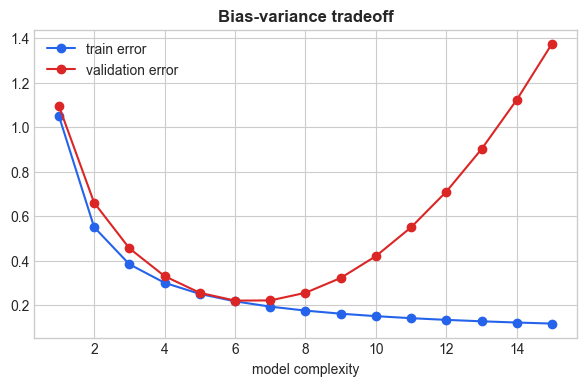

In [189]:
complexity = np.arange(1, 16)
train = 1 / complexity + 0.05
valid = 0.12 + 0.6/complexity + 0.015*(complexity-6)**2
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(complexity, train, marker="o", label="train error", color=COLORS["blue"])
ax.plot(complexity, valid, marker="o", label="validation error", color=COLORS["red"])
ax.set_title("Bias-variance tradeoff", weight="bold")
ax.set_xlabel("model complexity")
ax.legend()
plt.show()


**Graph explanation.** The wider histogram has larger variance. More spread around the mean means more uncertainty or variability.


## Block 95 - Convexity

**Concept.** A convex function has no hidden local minima.

**Notation.** $f(\lambda x+(1-\lambda)y)\le\lambda f(x)+(1-\lambda)f(y)$.

**Theory.** Convex optimization is easier because any local minimum is global.

**Math example.** $f(x)=x^2$ is convex; $f(x)=\sin(x)$ is not globally convex.

**Best ML/LLM example.** Linear/logistic regression losses are often convex; deep network losses are usually nonconvex.

**Visualization.** A convex bowl and a nonconvex curve are compared.


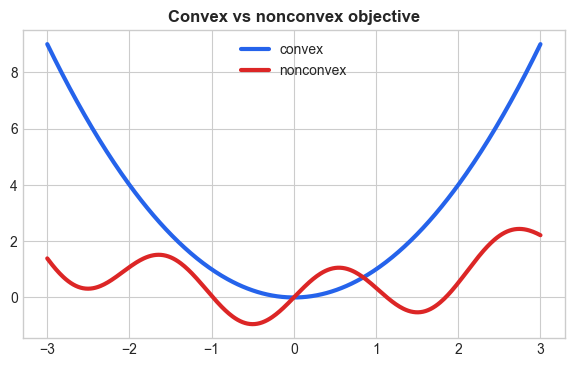

In [190]:
x = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, x**2, label="convex", color=COLORS["blue"], linewidth=3)
ax.plot(x, np.sin(3*x) + 0.2*x**2, label="nonconvex", color=COLORS["red"], linewidth=3)
ax.set_title("Convex vs nonconvex objective", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The convex curve has one clear basin, while the nonconvex curve has multiple bends. This explains why deep optimization can be difficult.


## Block 96 - Lagrange multipliers in depth

**Concept.** Lagrange multipliers solve optimization problems with equality constraints.

**Notation.** $\nabla f(x,y)=\lambda\nabla g(x,y)$ with constraint $g(x,y)=0$.

**Theory.** At the optimum, the objective contour is tangent to the constraint curve.

**Math example.** Maximize $xy$ subject to $x+y=1$.

**Best ML/LLM example.** Constrained objectives appear in normalization, maximum entropy, and SVM derivations.

**Visualization.** Contours touch the constraint at the constrained optimum.


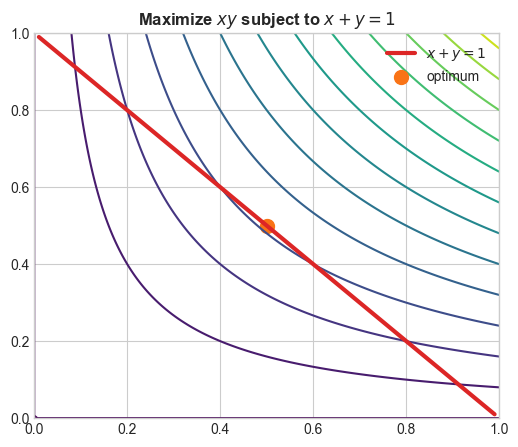

In [191]:
x = np.linspace(0.01, 0.99, 200)
y = 1 - x
Zx, Zy = np.meshgrid(np.linspace(0, 1, 150), np.linspace(0, 1, 150))
Z = Zx * Zy
fig, ax = plt.subplots(figsize=(6, 5))
ax.contour(Zx, Zy, Z, levels=12, cmap="viridis")
ax.plot(x, y, color=COLORS["red"], linewidth=3, label=r"$x+y=1$")
ax.scatter([0.5], [0.5], color=COLORS["orange"], s=100, label="optimum")
ax.set_title(r"Maximize $xy$ subject to $x+y=1$", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The optimum occurs where a contour just touches the constraint. At that point, gradients align.


## Block 97 - Numerical stability and log-sum-exp

**Concept.** Numerical stability prevents overflow, underflow, and loss of precision.

**Notation.** $\log\sum_i e^{x_i}=m+\log\sum_i e^{x_i-m}$ where $m=\max_i x_i$.

**Theory.** Subtracting the maximum keeps exponentials in a safe range.

**Math example.** $\exp(1000)$ overflows, but log-sum-exp remains finite.

**Best ML/LLM example.** Stable softmax and cross-entropy are essential in LLM training.

**Visualization.** Naive and stable log-sum-exp are compared.


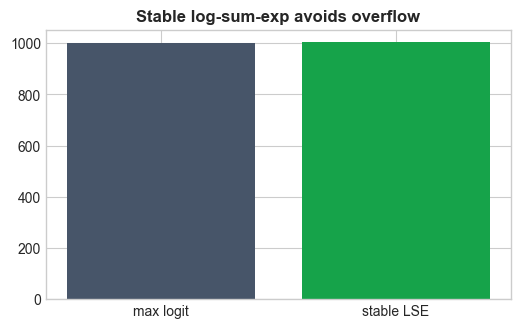

stable log-sum-exp = 1002.4076059644444


In [192]:
x = np.array([1000.0, 1001.0, 1002.0])
m = x.max()
stable_lse = m + np.log(np.sum(np.exp(x - m)))
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["max logit", "stable LSE"], [m, stable_lse], color=[COLORS["gray"], COLORS["green"]])
ax.set_title("Stable log-sum-exp avoids overflow", weight="bold")
plt.show()
print("stable log-sum-exp =", stable_lse)


**Graph explanation.** The stable computation keeps values finite by subtracting the maximum before exponentiating.


## Block 98 - Correlation vs covariance

**Concept.** Covariance measures joint movement in original units; correlation standardizes it to [-1, 1].

**Notation.** $\rho_{XY}=\frac{\operatorname{Cov}(X,Y)}{\sigma_X\sigma_Y}$.

**Theory.** Correlation is scale-free; covariance changes when units change.

**Math example.** Dollars and cents change covariance scale but not correlation.

**Best ML/LLM example.** Feature analysis often uses correlation to compare relationships across variables.

**Visualization.** Scaling one variable changes covariance but leaves correlation unchanged.


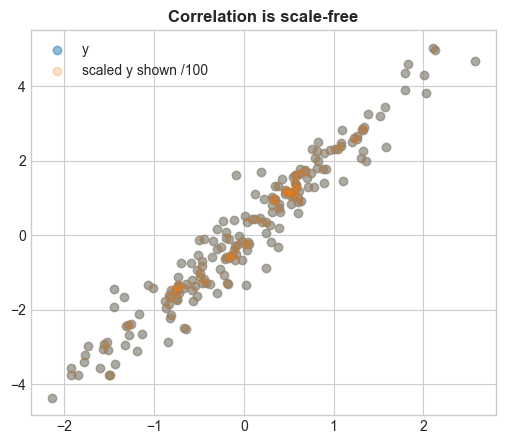

cov(x,y) = 1.7603942942754531 cov(x,100y) = 176.03942942754531
corr(x,y) = 0.9672979086831957 corr(x,100y) = 0.9672979086831954


In [193]:
rng = np.random.default_rng(11)
x = rng.normal(size=200)
y = 2*x + rng.normal(scale=0.5, size=200)
y_scaled = 100*y
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, alpha=0.5, label="y")
ax.scatter(x, y_scaled/100, alpha=0.25, label="scaled y shown /100")
ax.set_title("Correlation is scale-free", weight="bold")
ax.legend()
plt.show()
print("cov(x,y) =", np.cov(x,y)[0,1], "cov(x,100y) =", np.cov(x,y_scaled)[0,1])
print("corr(x,y) =", np.corrcoef(x,y)[0,1], "corr(x,100y) =", np.corrcoef(x,y_scaled)[0,1])


**Graph explanation.** The wider histogram has larger variance. More spread around the mean means more uncertainty or variability.


## Block 99 - Mutual information

**Concept.** Mutual information measures how much knowing one variable reduces uncertainty about another.

**Notation.** $I(X;Y)=\sum_{x,y}p(x,y)\log\frac{p(x,y)}{p(x)p(y)}$.

**Theory.** It is zero when variables are independent and positive when they are dependent.

**Math example.** A copied bit has high mutual information with the original bit.

**Best ML/LLM example.** Mutual information appears in representation learning and feature selection.

**Visualization.** A joint probability table is used to compute $I(X;Y)$.


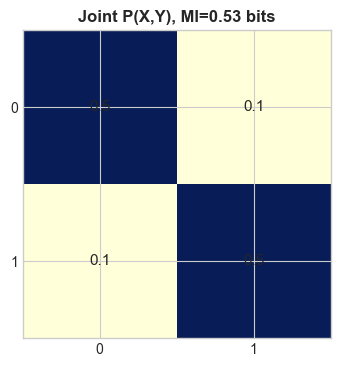

In [194]:
P = np.array([[0.45, 0.05], [0.05, 0.45]])
px = P.sum(axis=1, keepdims=True)
py = P.sum(axis=0, keepdims=True)
MI = np.sum(P * np.log2(P / (px @ py)))
fig, ax = plt.subplots(figsize=(4.5, 4))
show_matrix(ax, P, fr"Joint P(X,Y), MI={MI:.2f} bits", cmap="YlGnBu")
plt.show()


**Graph explanation.** The joint table concentrates probability on matching outcomes. That dependence produces positive mutual information.


## Block 100 - Markov chains

**Concept.** A Markov chain models a sequence where the next state depends only on the current state.

**Notation.** $P(X_{t+1}\mid X_t,\ldots,X_0)=P(X_{t+1}\mid X_t)$.

**Theory.** Transition matrices encode probabilities of moving between states.

**Math example.** Weather tomorrow depends on weather today in a simple Markov weather model.

**Best ML/LLM example.** Markov assumptions appear in sequence modeling history, HMMs, and sampling processes.

**Visualization.** Repeated multiplication by a transition matrix evolves a distribution.


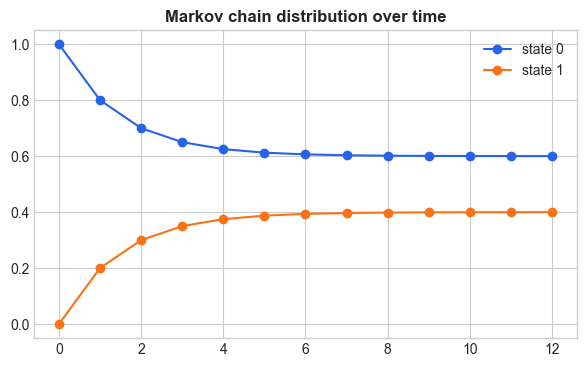

In [195]:
P = np.array([[0.8, 0.2], [0.3, 0.7]])
dist = np.array([1.0, 0.0])
history = [dist]
for _ in range(12):
    dist = dist @ P
    history.append(dist)
history = np.array(history)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history[:,0], marker="o", label="state 0", color=COLORS["blue"])
ax.plot(history[:,1], marker="o", label="state 1", color=COLORS["orange"])
ax.set_title("Markov chain distribution over time", weight="bold")
ax.legend()
plt.show()


**Graph explanation.** The lines show how state probabilities evolve over repeated transitions. Eventually the distribution tends toward a stable mix.


## Block 101 - Monte Carlo estimation

**Concept.** Monte Carlo methods estimate quantities using random samples.

**Notation.** $\mathbb{E}[f(X)]\approx\frac{1}{N}\sum_{i=1}^N f(x_i)$.

**Theory.** More samples usually reduce estimation error at a rate around $1/\sqrt{N}$.

**Math example.** Estimate $\pi$ by sampling points inside a square and counting those inside a circle.

**Best ML/LLM example.** Sampling-based estimates appear in Bayesian inference, reinforcement learning, and evaluation.

**Visualization.** Random points estimate the area of a quarter circle.


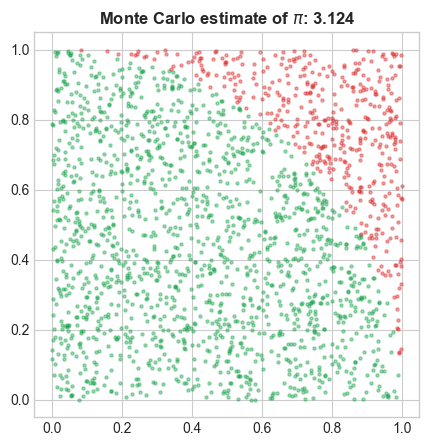

In [196]:
rng = np.random.default_rng(12)
N = 2000
pts = rng.random((N, 2))
inside = np.sum(pts**2, axis=1) <= 1
pi_hat = 4 * inside.mean()
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pts[inside,0], pts[inside,1], s=5, alpha=0.4, color=COLORS["green"])
ax.scatter(pts[~inside,0], pts[~inside,1], s=5, alpha=0.4, color=COLORS["red"])
ax.set_aspect("equal")
ax.set_title(fr"Monte Carlo estimate of $\pi$: {pi_hat:.3f}", weight="bold")
plt.show()


**Graph explanation.** The random points estimate area by counting how many fall inside the circle. More samples usually improve the estimate.


## Final Capstone - One small PCA pipeline using many ideas

This capstone ties together vectors, matrices, centering, covariance, eigenvectors, projection, and rank-1 reconstruction.

**Challenge.** After running it, answer these questions:

- Which line is the main direction of variation?
- Why is the reconstruction called rank-1?
- What information is lost when data is projected onto one direction?


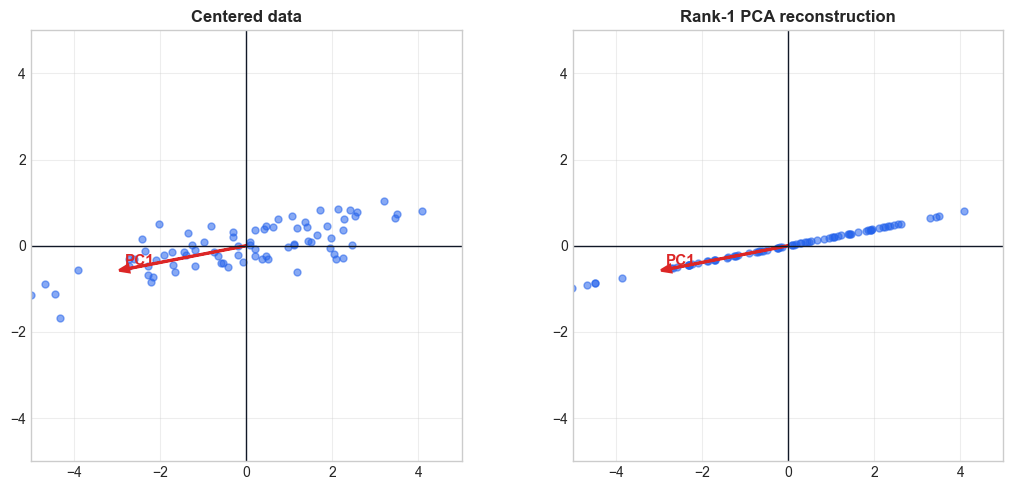

Covariance:
 [[4.515 0.855]
 [0.855 0.282]]
Dominant principal direction: [-0.982 -0.191]


In [197]:
rng = np.random.default_rng(21)
X = rng.normal(size=(80, 2)) @ np.array([[2.0, 0.8], [0.2, 0.5]]).T + np.array([3, -1])
X_centered = X - X.mean(axis=0)
C = np.cov(X_centered, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(C)
pc1 = eigvecs[:, eigvals.argmax()]
projection_scores = X_centered @ pc1
X_rank1 = np.outer(projection_scores, pc1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, data, title in [(axes[0], X_centered, "Centered data"), (axes[1], X_rank1, "Rank-1 PCA reconstruction")]:
    setup_2d_axis(ax, limit=5, title=title)
    ax.scatter(data[:,0], data[:,1], s=25, alpha=0.55, color=COLORS["blue"])
    draw_vector(ax, pc1 * 3, color=COLORS["red"], label="PC1")
plt.tight_layout()
plt.show()
print("Covariance:\n", C)
print("Dominant principal direction:", pc1)


**Graph explanation.** The first plot shows the centered data cloud, and the second plot shows the rank-1 reconstruction after projecting onto the dominant principal component. The difference between them is the information lost when keeping only one direction of variation.
